## Import

In [1]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.neural_network import MLPRegressor

In [2]:
from ML.utils.utils import *
from ML.utils.Data_preparator import Data_preparator
from ML.utils.Model_evaluator import Model_evaluator
from physics.Iso_data_handler import Iso_data_handler
from physics.Data_visualiser import Data_visualiser

In [3]:
pre_path = "../../../../../../../"
physical_model = "MIST"
path_to_data = pre_path + "data/MIST_v1.2_vvcrit0.0_basic_isos/"
path_to_results = pre_path + "results/model_A_partial/default_models/"
path_to_predictions = pre_path + "predictions/model_A_partial/default_models/"
tag = "scale_power"
output_parameters = ['mass', 'radius']
categories_name = ["phase"]

In [4]:
override = True
use_preds = False
save = True
show = True
scaler_name = "power"

## Data preparation

This notebook contains the results of the model which are trained using all the data from MIST and filtered on the phases

Reading MIST dataframe from MIST_reclassified_iso_full_data.csv file...


,log10_isochrone_age_yr,log_Teff,log_g,phase,metallicity,star_mass,log_R
0,5.0,3.486221,3.131342,-1.0,-0.25,0.100000,0.153402
1,5.0,3.487362,3.126808,-1.0,-0.25,0.102645,0.160326
2,5.0,3.489243,3.119367,-1.0,-0.25,0.107039,0.171785
3,5.0,3.491102,3.112165,-1.0,-0.25,0.111419,0.183099
4,5.0,3.492937,3.105143,-1.0,-0.25,0.115789,0.194305
...,...,...,...,...,...,...,...
1467117,10.3,4.402490,7.777159,6.0,0.50,0.532726,-1.806255
1467118,10.3,4.387132,7.783242,6.0,0.50,0.532730,-1.809295
1467119,10.3,4.371789,7.789130,6.0,0.50,0.532735,-1.812237
1467120,10.3,4.356480,7.794844,6.0,0.50,0.532741,-1.815091


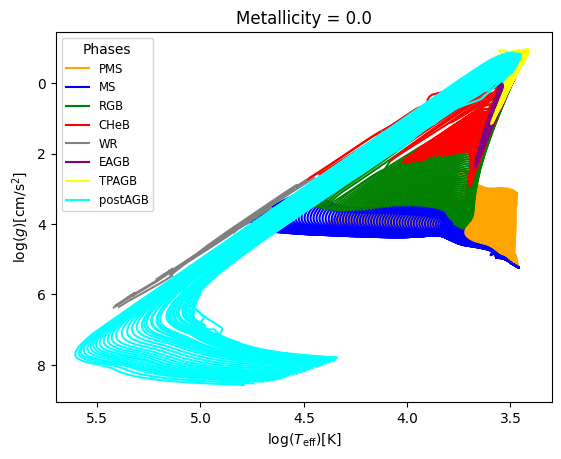

In [5]:
iso_handler = Iso_data_handler(path_to_data, 
                              ['log10_isochrone_age_yr', 'log_Teff', 'log_g', 'phase', 'metallicity', 'star_mass', 'log_R'], 
                              physical_model, reclassify=True)

iso_df = iso_handler.get_isochrone_dataframe()
display(iso_df)
data_visualiser = Data_visualiser(iso_df, physical_model)
data_visualiser.plot_Kiel([], [0.0])

,log10_isochrone_age_yr,log_Teff,log_g,phase,metallicity,star_mass,log_R
0,5.0,4.494412,4.346972,0.0,-0.25,13.584360,0.610679
1,5.0,4.497517,4.345776,0.0,-0.25,13.765512,0.614753
2,5.0,4.500556,4.344580,0.0,-0.25,13.942887,0.618755
3,5.0,4.504040,4.343050,0.0,-0.25,14.591712,0.624670
4,5.0,4.507576,4.341483,0.0,-0.25,15.426062,0.631187
...,...,...,...,...,...,...,...
630600,10.3,3.602322,1.827453,3.0,0.50,0.866616,1.274247
630601,10.3,3.600999,1.809405,3.0,0.50,0.866614,1.283270
630602,10.3,3.599710,1.791489,3.0,0.50,0.866612,1.292228
630603,10.3,3.598418,1.773621,3.0,0.50,0.866610,1.301161


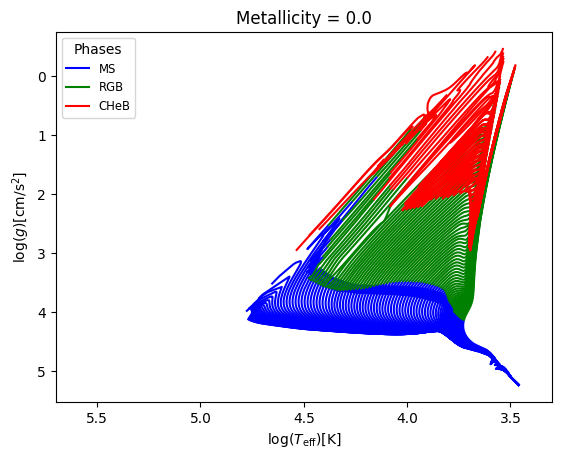

In [6]:
phase_filtered_iso_df = Data_preparator.filter_data(iso_df, {'phase':[0, 2, 3]})
display(phase_filtered_iso_df)
data_visualiser_phase_filtered = Data_visualiser(phase_filtered_iso_df, physical_model)
data_visualiser_phase_filtered.plot_Kiel([], [0.0])

In [7]:
print_all_uniques(phase_filtered_iso_df)

log10_isochrone_age_yr  : Range : 5.0 - 10.3, Mean : 8.1154, Median : 8.15

log_Teff  : Range : 3.34 - 5.3788, Mean : 4.0283, Median : 3.9761

log_g  : Range : -1.08 - 6.2594, Mean : 3.5075, Median : 3.8521

Values in phase column : 0.0, 2.0, 3.0 

Values in metallicity column : -0.25, -0.5, -0.75, -1.0, -1.25, -1.5, -1.75, -2.0, -2.5, -3.0, -3.5, -4.0, 0.0, 0.25, 0.5 

star_mass  : Range : 0.1 - 298.5448, Mean : 11.4145, Median : 2.8996

log_R  : Range : -1.0 - 3.1298, Mean : 0.735, Median : 0.7005



In [8]:
X_train, X_ivs, y_train, y_ivs, categories_train, categories_ivs = \
    Data_preparator.split_data(phase_filtered_iso_df, x_cols=['log10_isochrone_age_yr', 'log_Teff', 'log_g', 'metallicity'], 
                               y_cols=['star_mass', 'log_R'], categories_cols=['phase'], random_state=12, print_stats=True)

print(X_train.shape, X_ivs.shape)
print(y_train.shape, y_ivs.shape)

Training set statistics:
Range in train data for the star_mass parameter : 0.0999979840073621 - 298.5447575808816
Median value in train data for the star_mass parameter: 2.900660435695107
Mean value in train data for the star_mass parameter: 11.448959764246645

Range in train data for the log_R parameter : -0.9974628481553472 - 3.129269620812593
Median value in train data for the log_R parameter: 0.7005259212303901
Mean value in train data for the log_R parameter: 0.7346615625058007

Testing set statistics:
Range in test data for the star_mass parameter : 0.0999984244466985 - 295.93050489035244
Median value in test data for the star_mass parameter: 2.89581954298918
Mean value in test data for the star_mass parameter: 11.31127918999169

Range in test data for the log_R parameter : -0.9974747647513328 - 3.1297545143214007
Median value in test data for the log_R parameter: 0.700308157259431
Mean value in test data for the log_R parameter: 0.7362027655401773

(472953, 4) (157652, 4)
(47295

## Model training

### Linear regression

In [9]:
lr_evaluator = Model_evaluator("linear_regression", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


scale_power train data :
Performing K-fold...
Split 1 2 3 4 5 6 7 8 9 10 
Evaluating predictions...

mass results for the phase category with a value of 0.0
  value range :  0.0999979840073621 - 298.5447575808816
  RVE :  0.23962151037570645
  RMSE :  22.939327050945167
  MAE :  13.091369867161145
  MedAE :  10.896269024397407
  CORR :  0.5007752690272543
  MAX_ER :  263.45405704138386
  Percentiles : 
    75th percentile :  14.646919065568921
    90th percentile :  19.086211880598746
    95th percentile :  21.87775163940467
    99th percentile :  106.6279797134351

mass results for the phase category with a value of 2.0
  value range :  0.6538581961218565 - 283.72102985530483
  RVE :  0.2966175810286509
  RMSE :  24.904246850670656
  MAE :  10.837388535352623
  MedAE :  6.622174872455034
  CORR :  0.5748569584004691
  MAX_ER :  248.7639294993681
  Percentiles : 
    75th percentile :  11.971209482056095
    90th percentile :  14.171805580503744
    95th percentile :  24.7178569907958

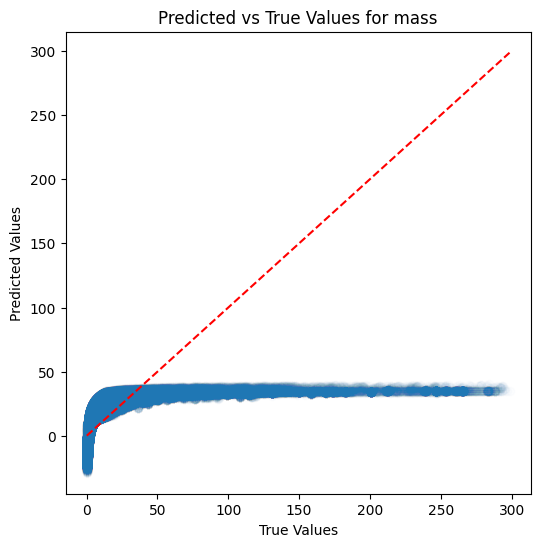

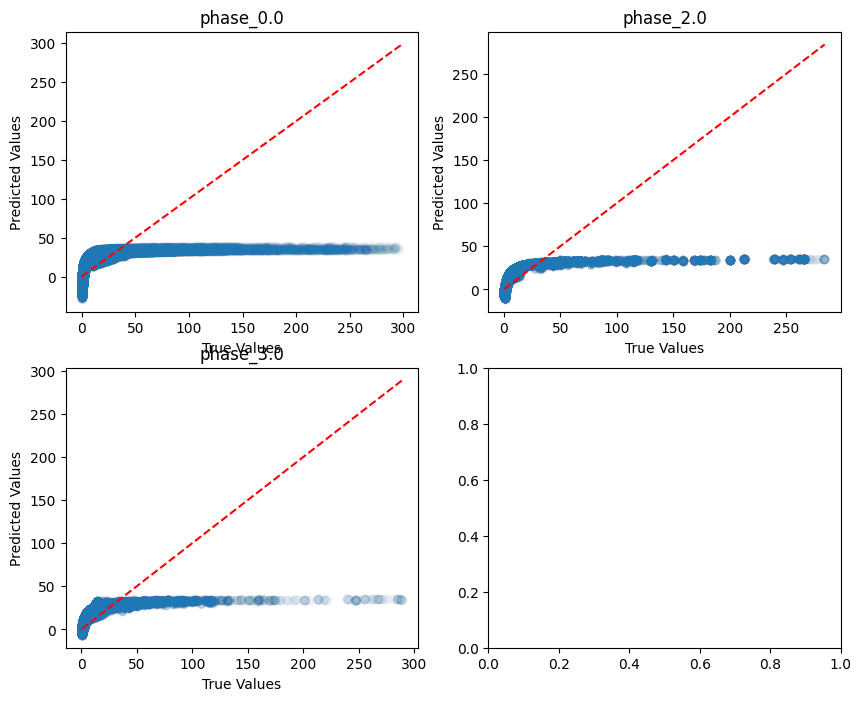

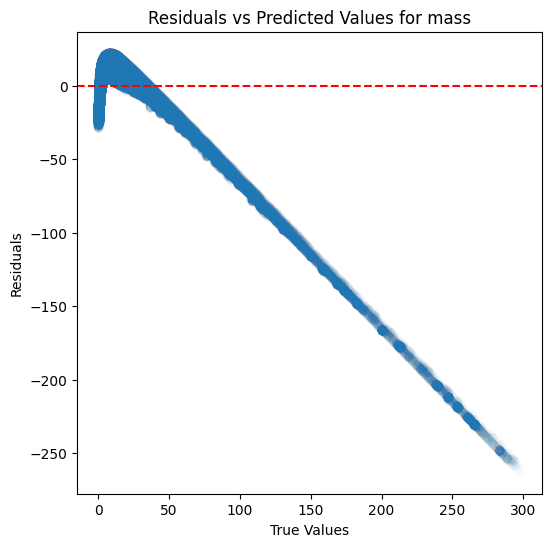

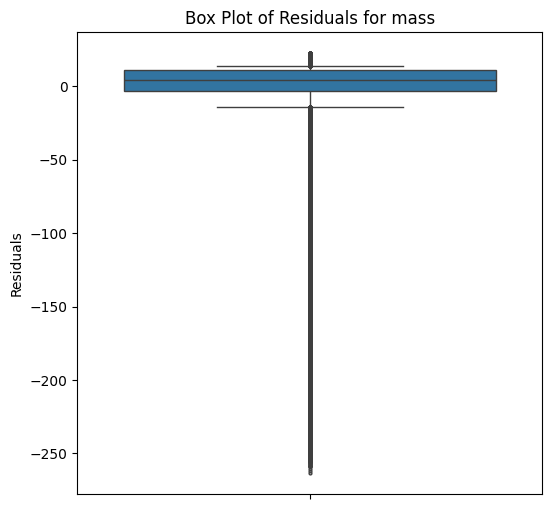

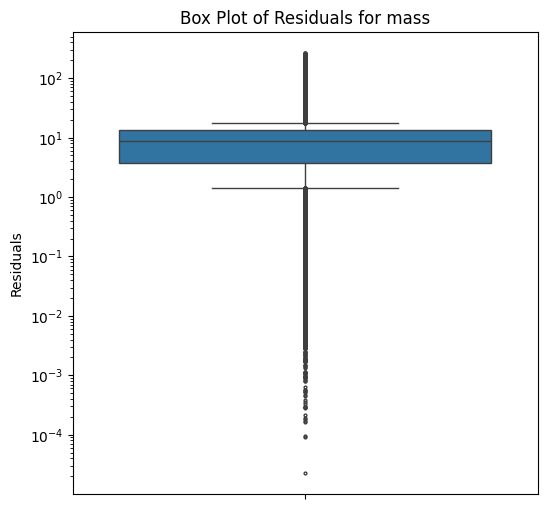

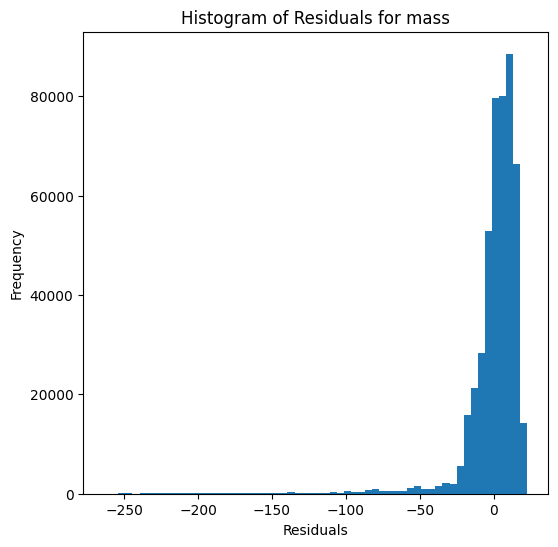

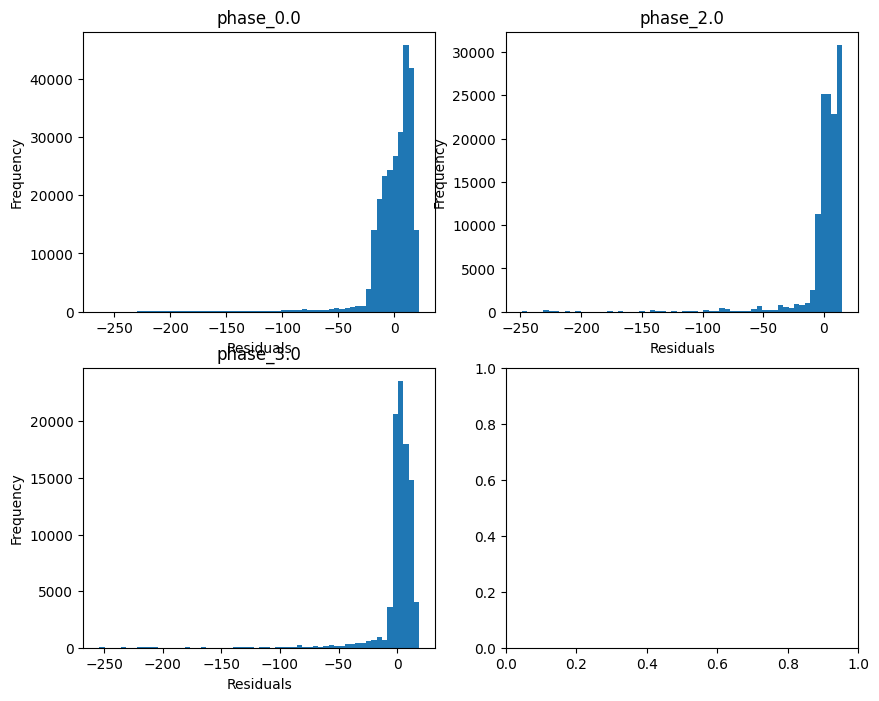

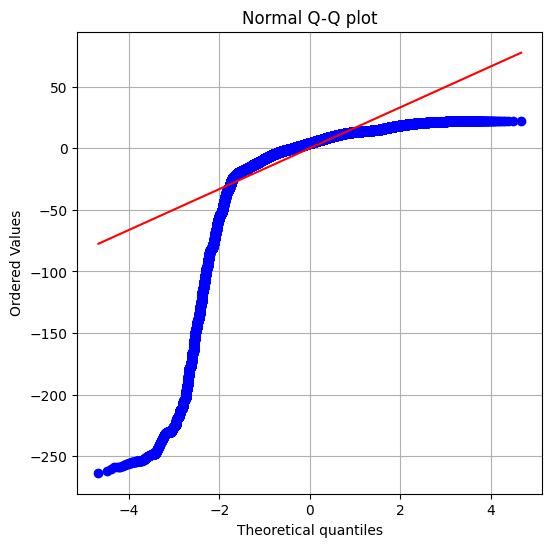

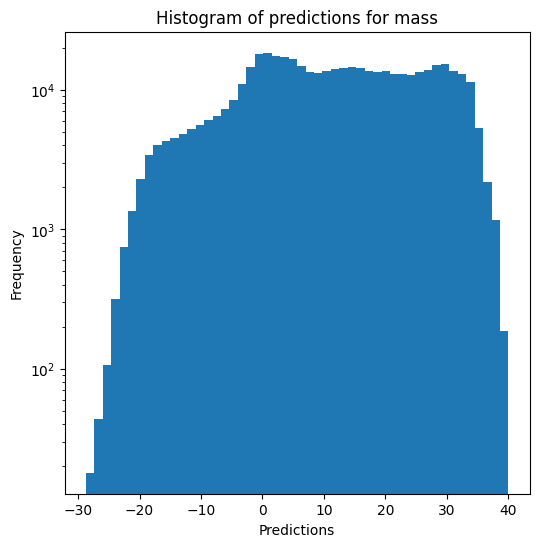

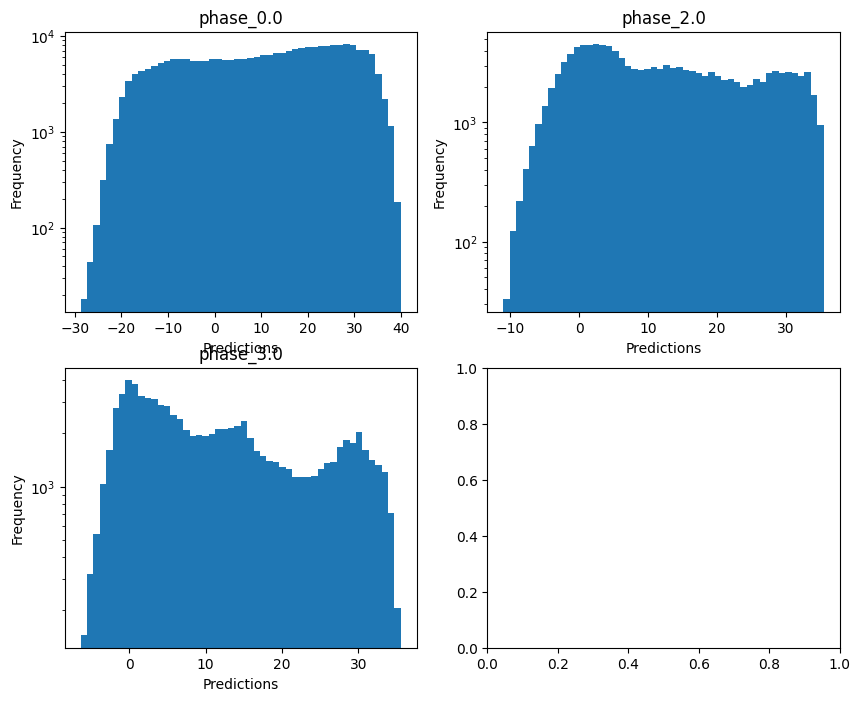

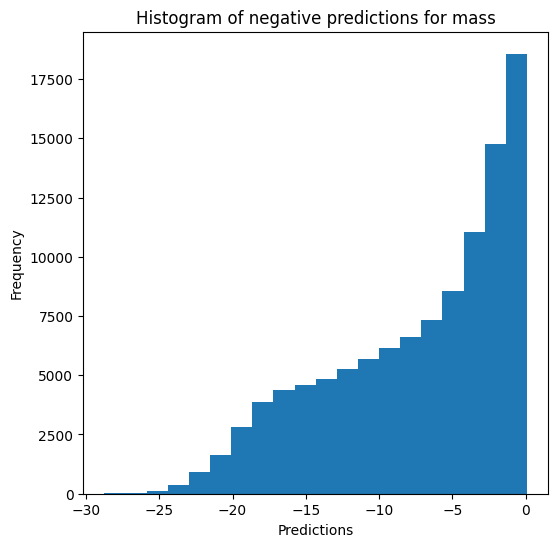


radius results for the phase category with a value of 0.0
  value range :  -0.9974628481553472 - 3.0827540579576227
  RVE :  0.9544928392458343
  RMSE :  0.12315512091414893
  MAE :  0.09489786542595852
  MedAE :  0.07527757472893482
  CORR :  0.9771381293337085
  MAX_ER :  0.6996590687813726
  Percentiles : 
    75th percentile :  0.1363584356863865
    90th percentile :  0.19997524034273867
    95th percentile :  0.23423764080573353
    99th percentile :  0.3669097435824347

radius results for the phase category with a value of 2.0
  value range :  0.0919862423867022 - 2.891706235288321
  RVE :  0.9470109780254621
  RMSE :  0.11862211618923213
  MAE :  0.09854303840354647
  MedAE :  0.09568776606769225
  CORR :  0.9754424635731059
  MAX_ER :  0.5934971352094995
  Percentiles : 
    75th percentile :  0.1300854876319817
    90th percentile :  0.15468836079554155
    95th percentile :  0.20785416661619707
    99th percentile :  0.37133965725473617

radius results for the phase categor

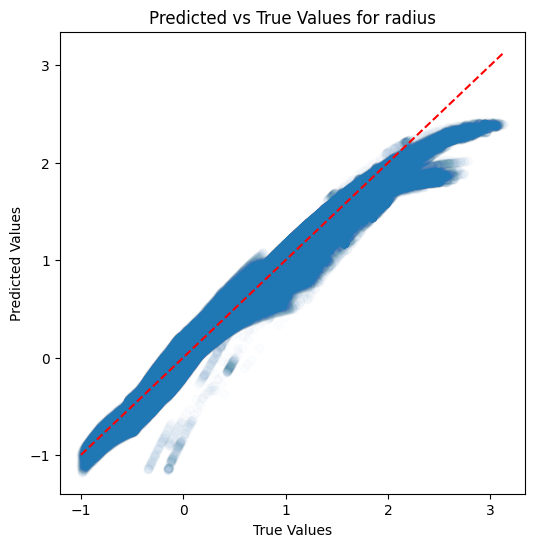

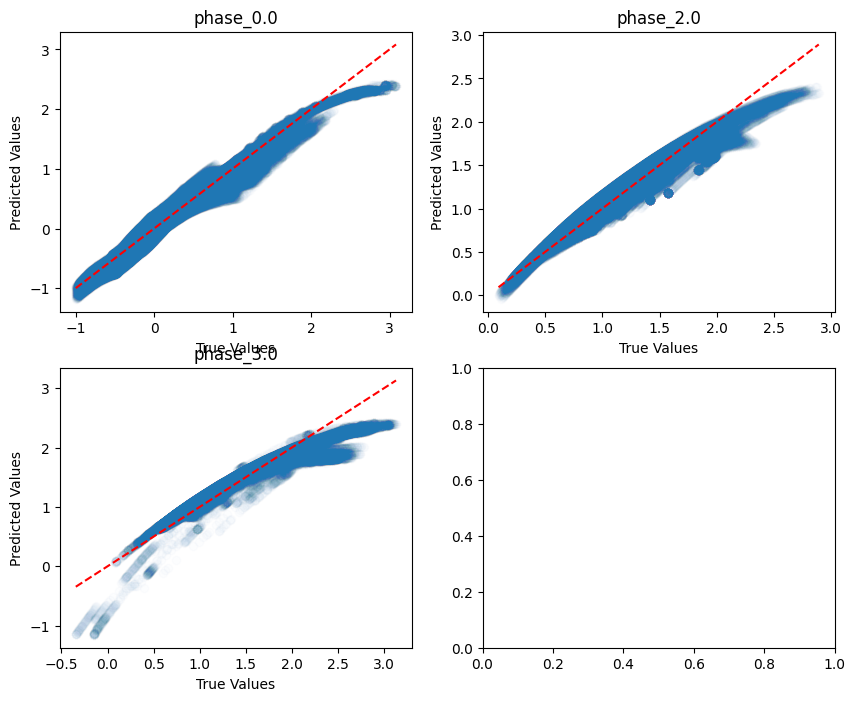

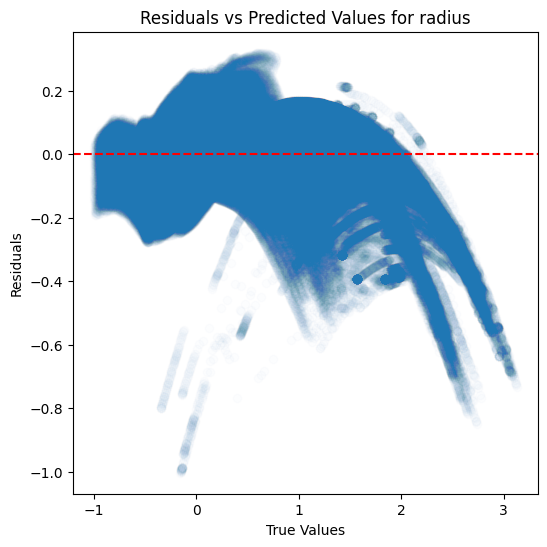

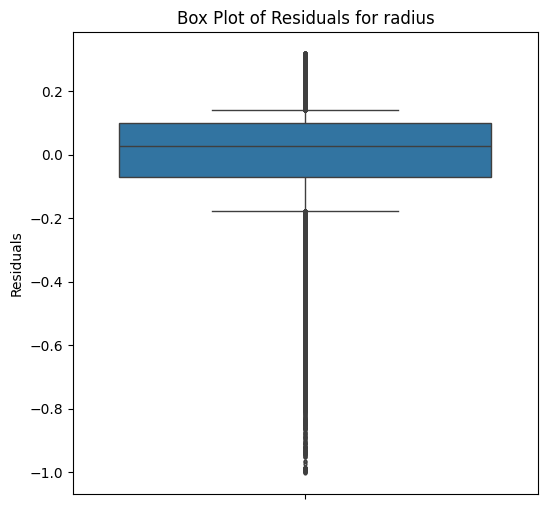

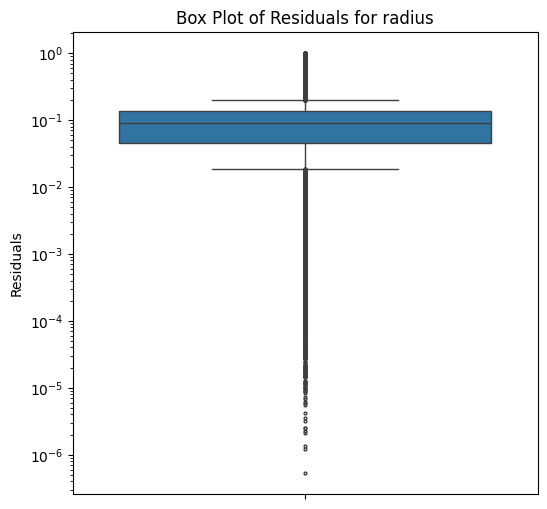

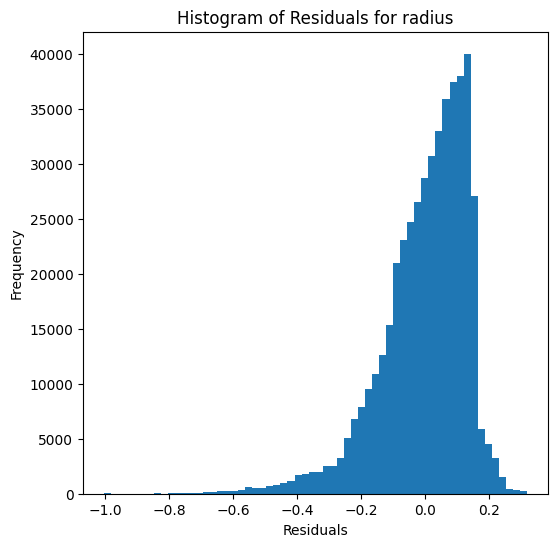

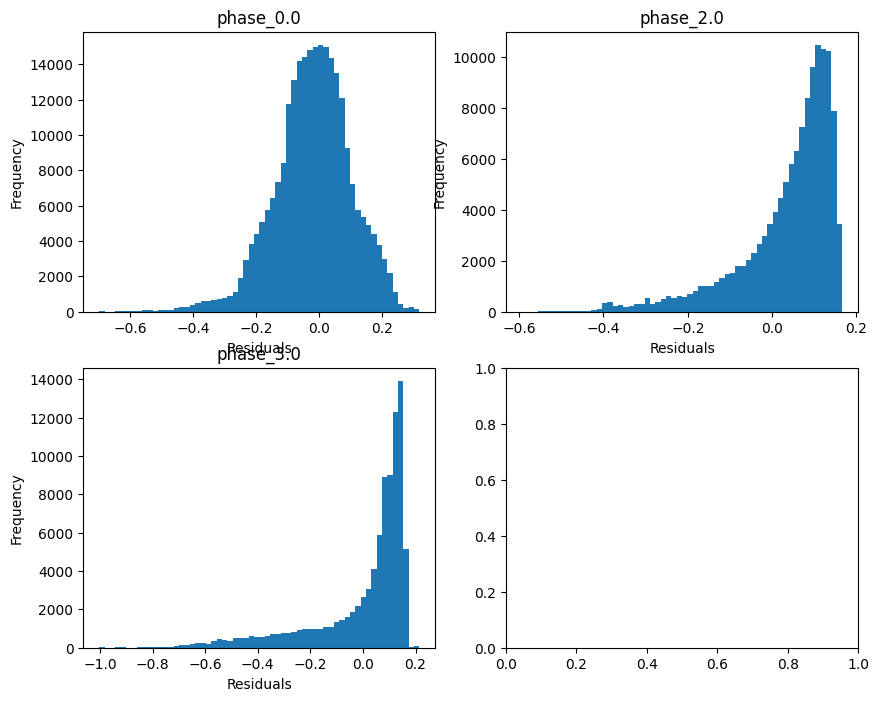

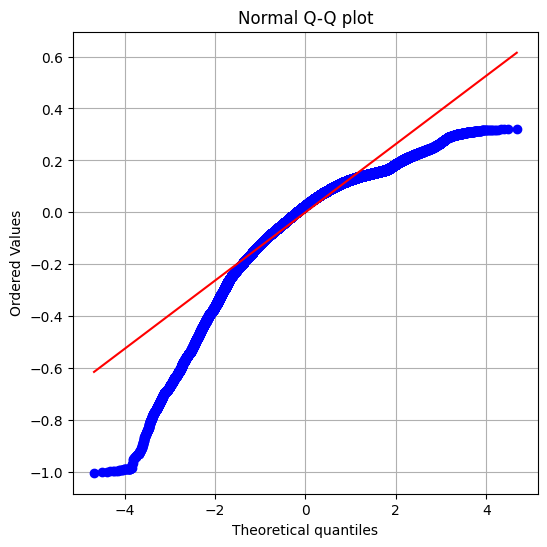

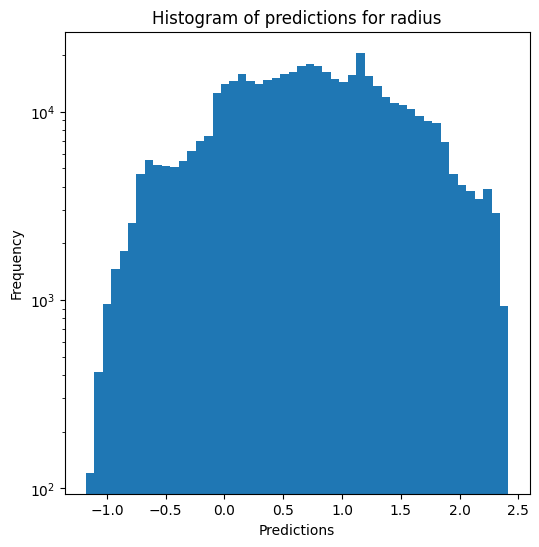

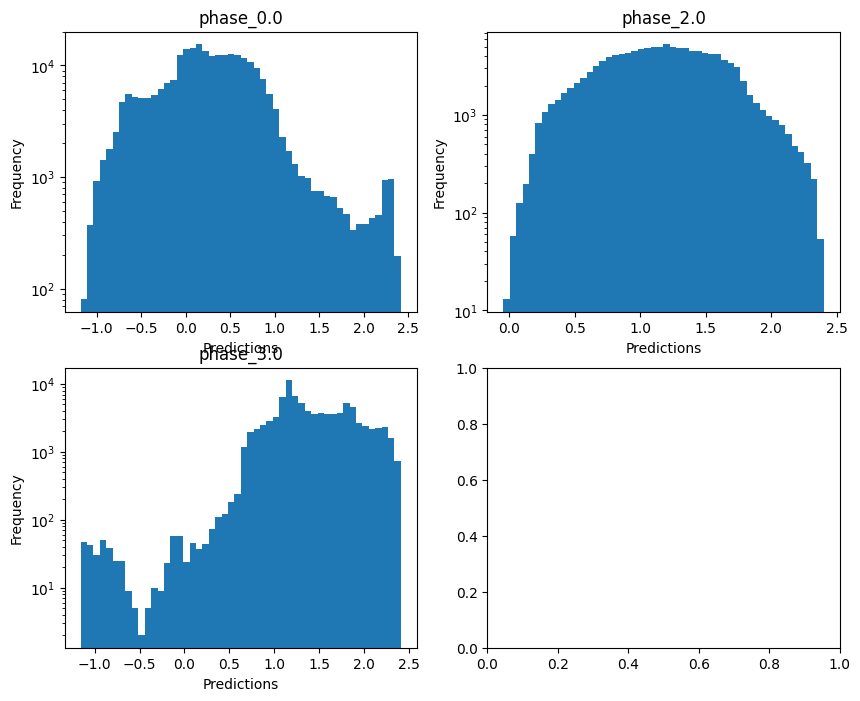

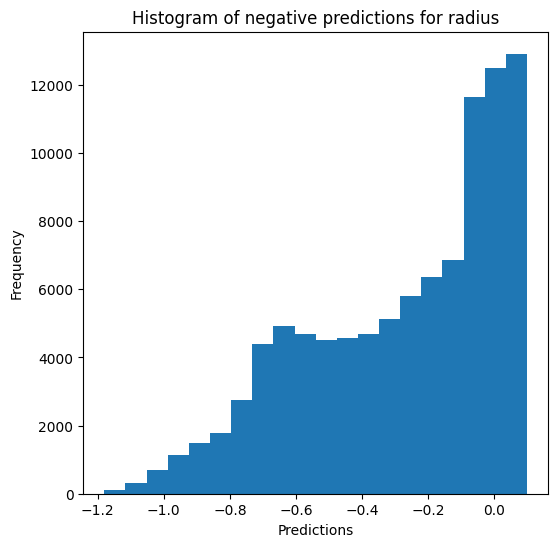

Saving predictions and results...


In [10]:
lr_evaluator.evaluate_Kfold_results(LinearRegression, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=override, use_preds=use_preds, save=save, show=show, scaler_name=scaler_name) #, override=False, use_preds=True

### Decision tree

In [11]:
dt_evaluator = Model_evaluator("decision_tree", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


scale_power train data :
Performing K-fold...
Split 1 2 3 4 5 6 7 8 9 10 
Evaluating predictions...

mass results for the phase category with a value of 0.0
  value range :  0.0999979840073621 - 298.5447575808816
  RVE :  0.9937584584493031
  RMSE :  2.077876914870414
  MAE :  0.26819738371167917
  MedAE :  0.005926281497792396
  CORR :  0.9968912616444416
  MAX_ER :  131.77529017024463
  Percentiles : 
    75th percentile :  0.03097399319085703
    90th percentile :  0.18528647525610728
    95th percentile :  0.6717010531065343
    99th percentile :  5.858657137497829

mass results for the phase category with a value of 2.0
  value range :  0.6538581961218565 - 283.72102985530483
  RVE :  0.9992314927358148
  RMSE :  0.8232057434925504
  MAE :  0.0607401276240524
  MedAE :  0.0003557218574223864
  CORR :  0.9996158058322198
  MAX_ER :  104.41505908998724
  Percentiles : 
    75th percentile :  0.005503798604353849
    90th percentile :  0.025461385450042354
    95th percentile :  0.0

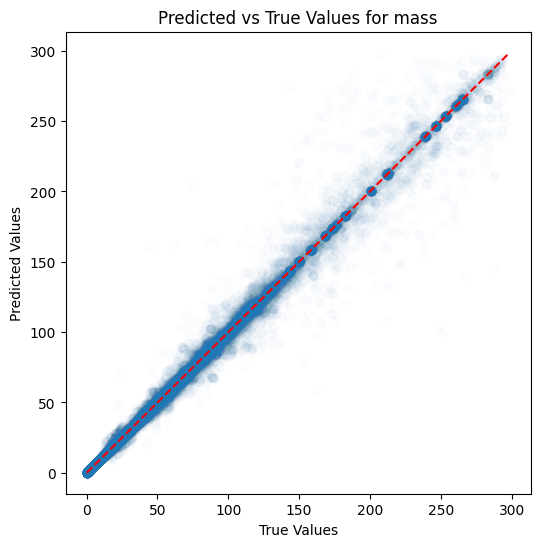

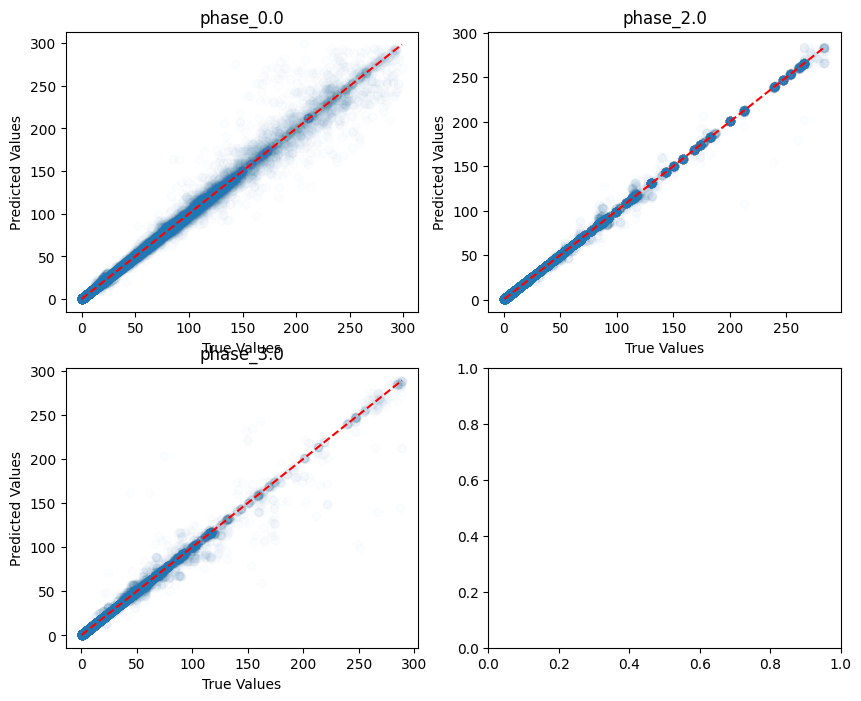

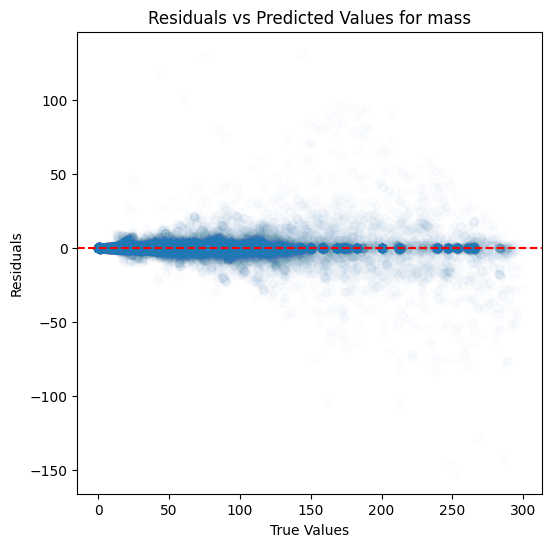

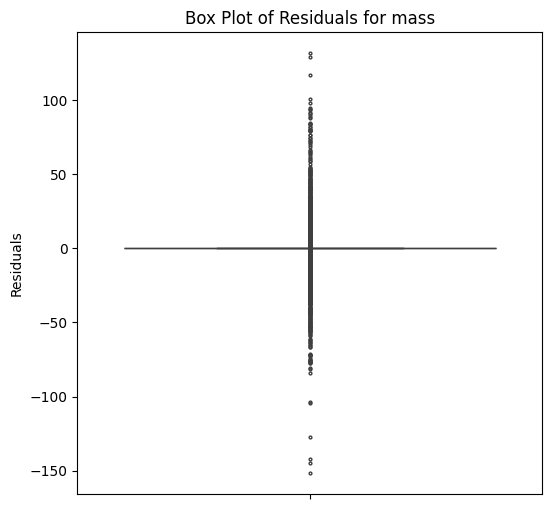

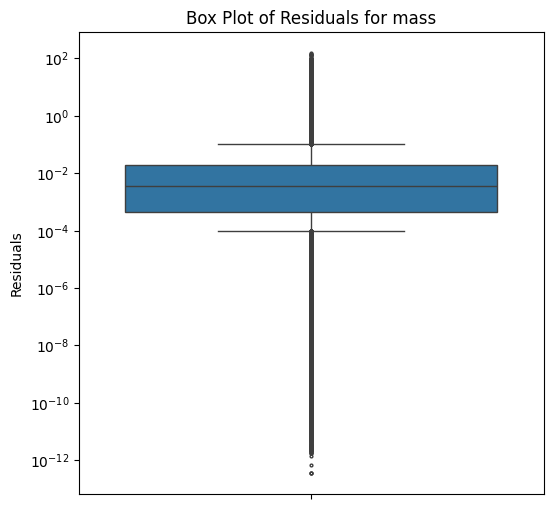

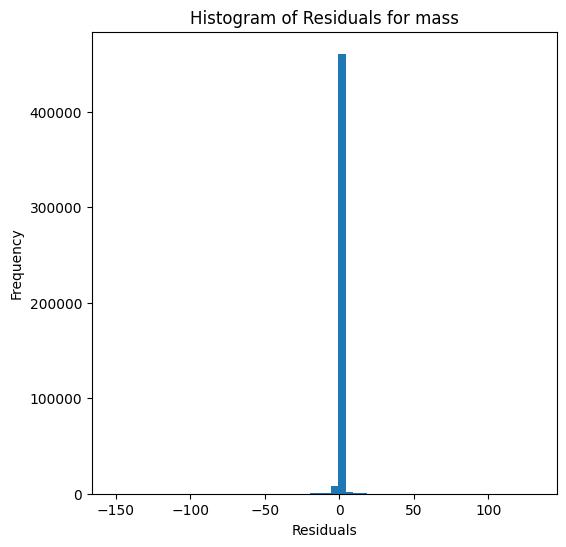

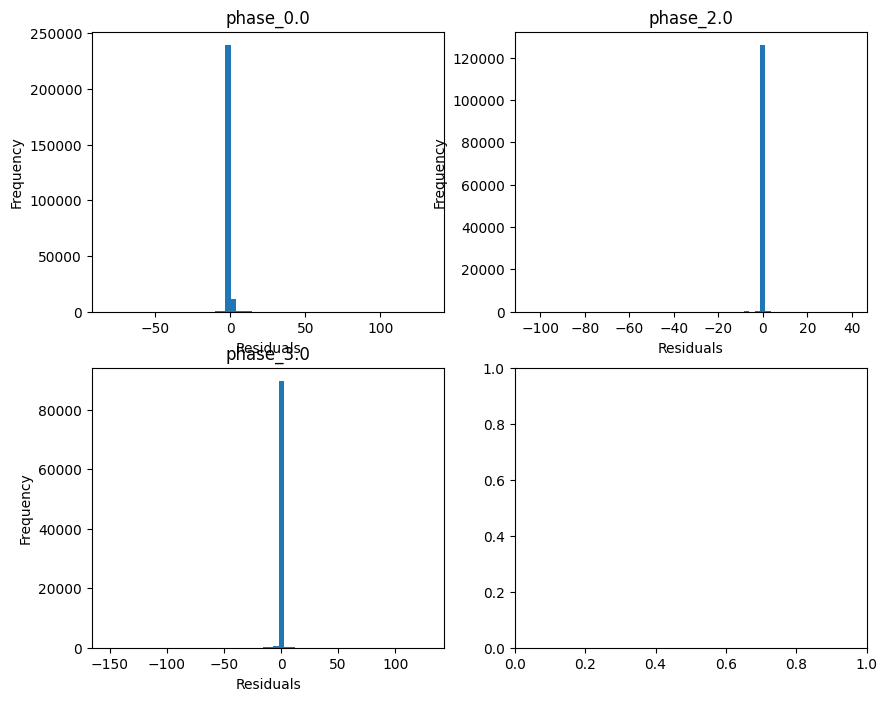

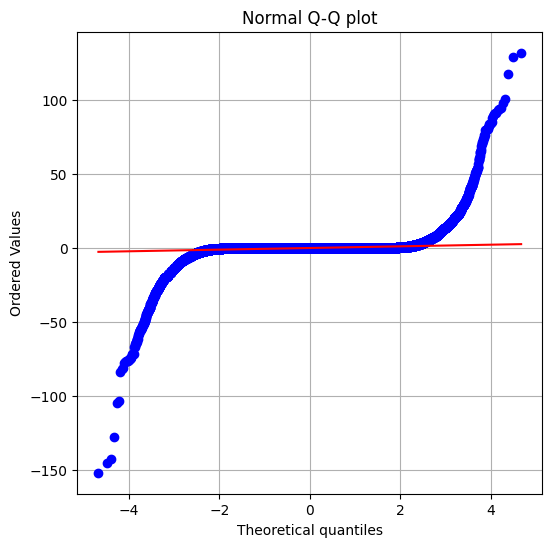

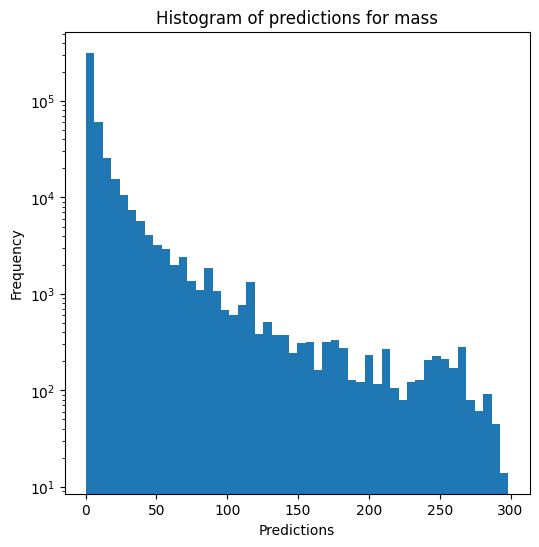

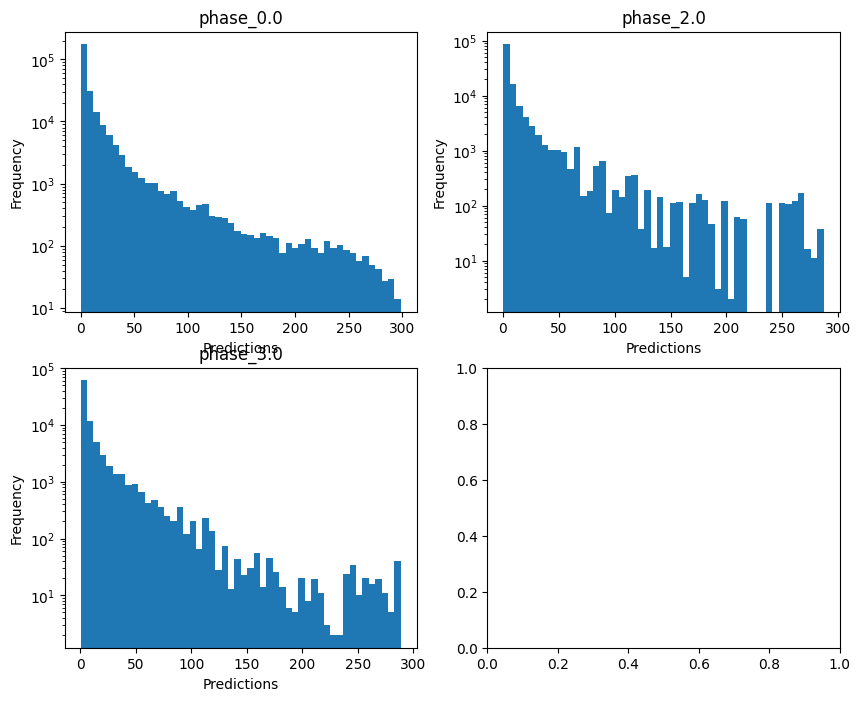

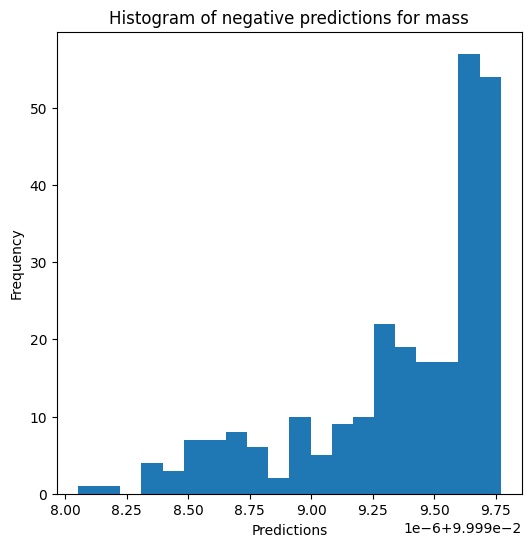


radius results for the phase category with a value of 0.0
  value range :  -0.9974628481553472 - 3.0827540579576227
  RVE :  0.9997836068122534
  RMSE :  0.008390371197816507
  MAE :  0.004594051513109393
  MedAE :  0.0026181168457588
  CORR :  0.9998918428007688
  MAX_ER :  0.48792609242004326
  Percentiles : 
    75th percentile :  0.005343447609098939
    90th percentile :  0.01027689950437173
    95th percentile :  0.015136792348243056
    99th percentile :  0.03238807464454734

radius results for the phase category with a value of 2.0
  value range :  0.0919862423867022 - 2.891706235288321
  RVE :  0.9995960147556129
  RMSE :  0.009875409608738683
  MAE :  0.006748748166840736
  MedAE :  0.0052248952172626595
  CORR :  0.9997989654044362
  MAX_ER :  0.1724792763407461
  Percentiles : 
    75th percentile :  0.009072979015171623
    90th percentile :  0.013456753303607627
    95th percentile :  0.016635426600504318
    99th percentile :  0.031560006294072386

radius results for th

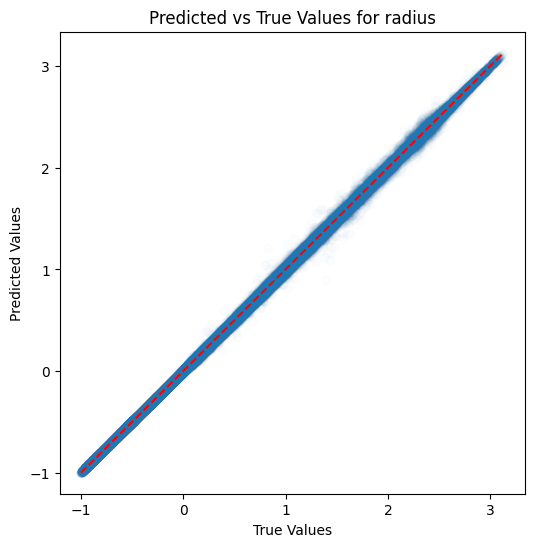

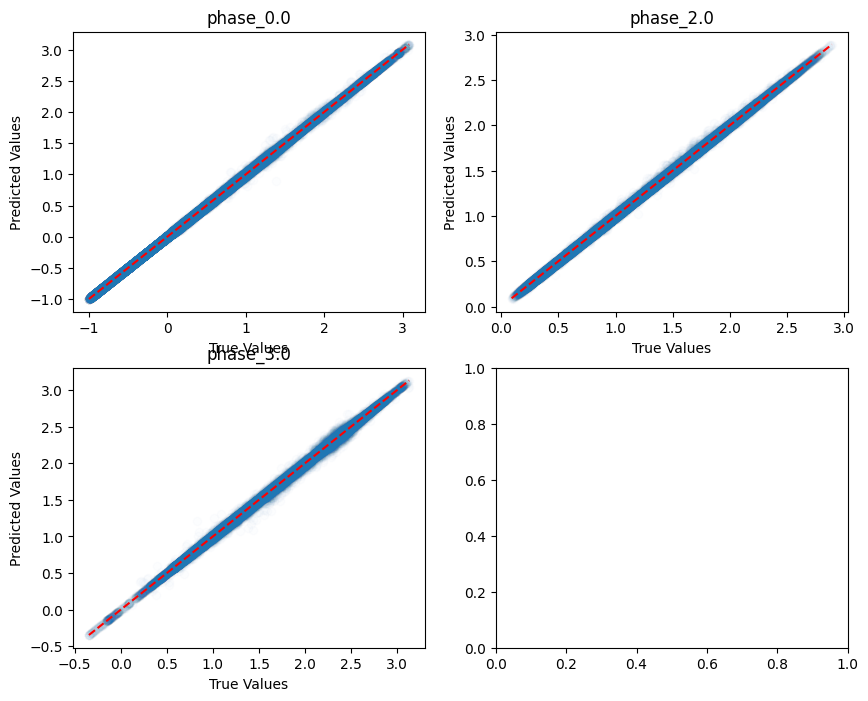

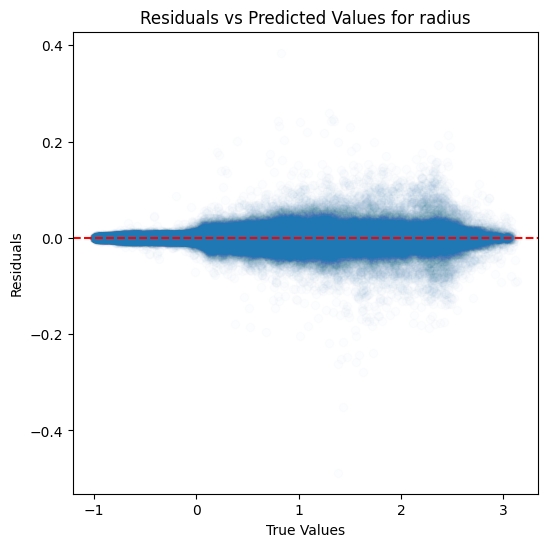

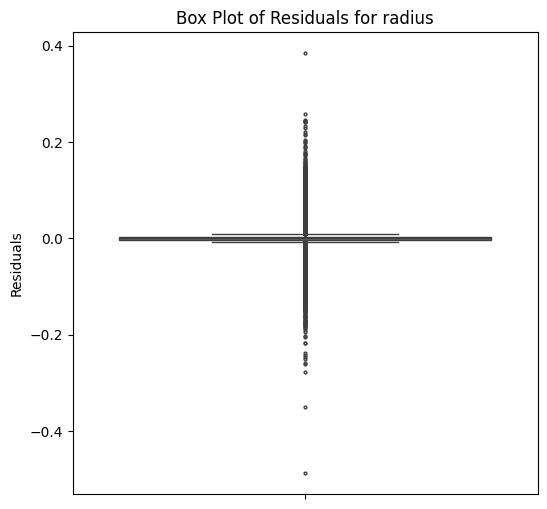

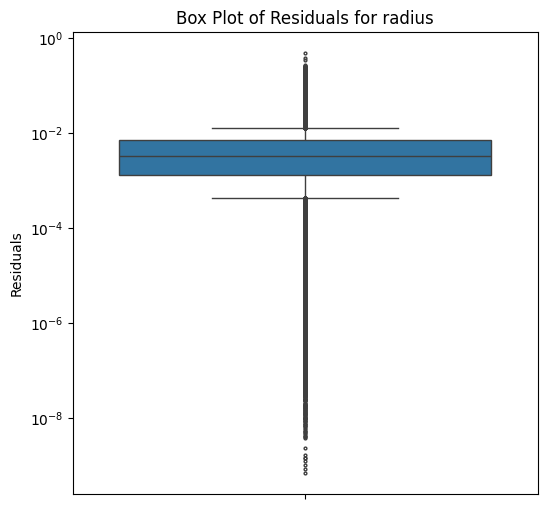

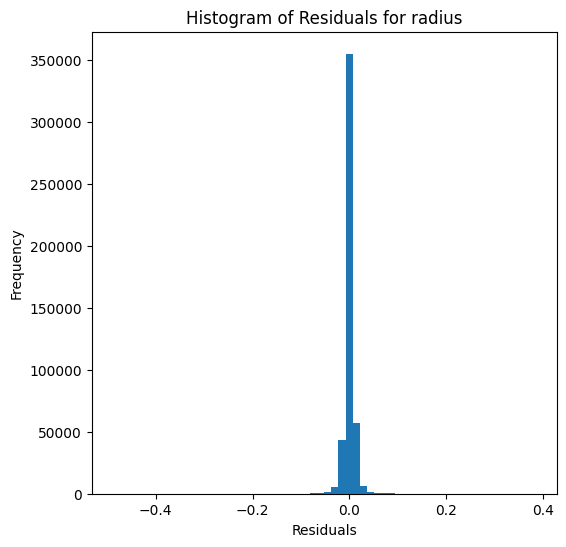

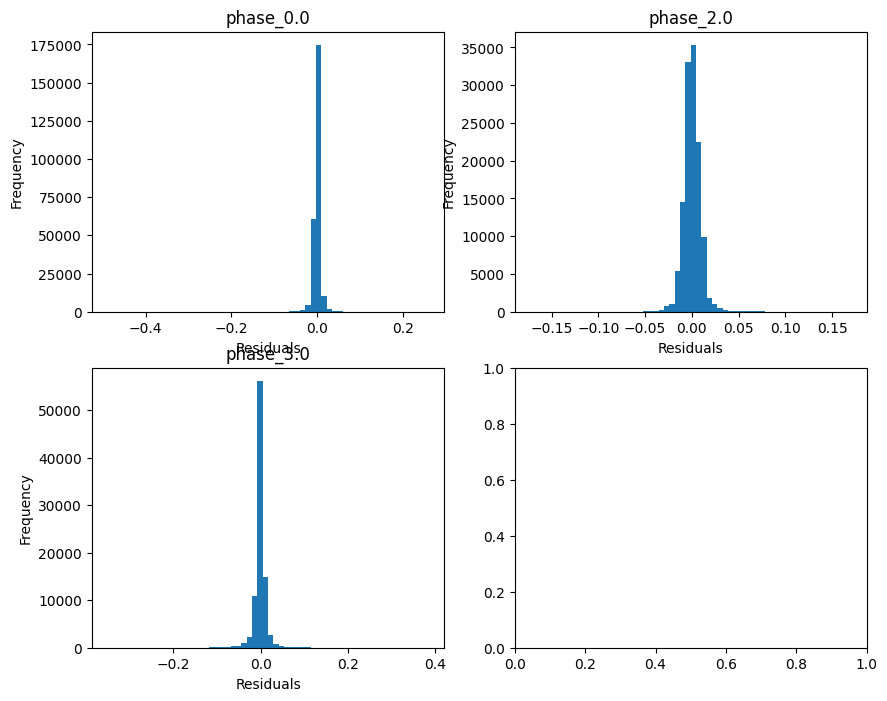

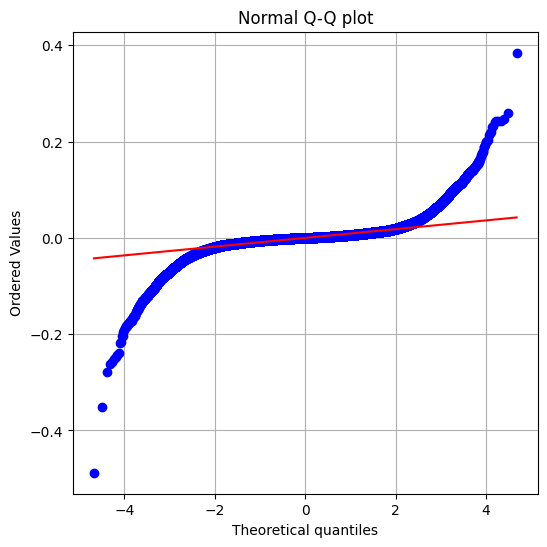

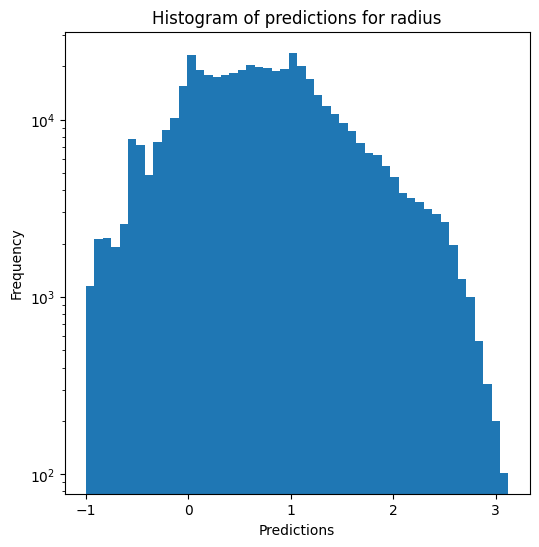

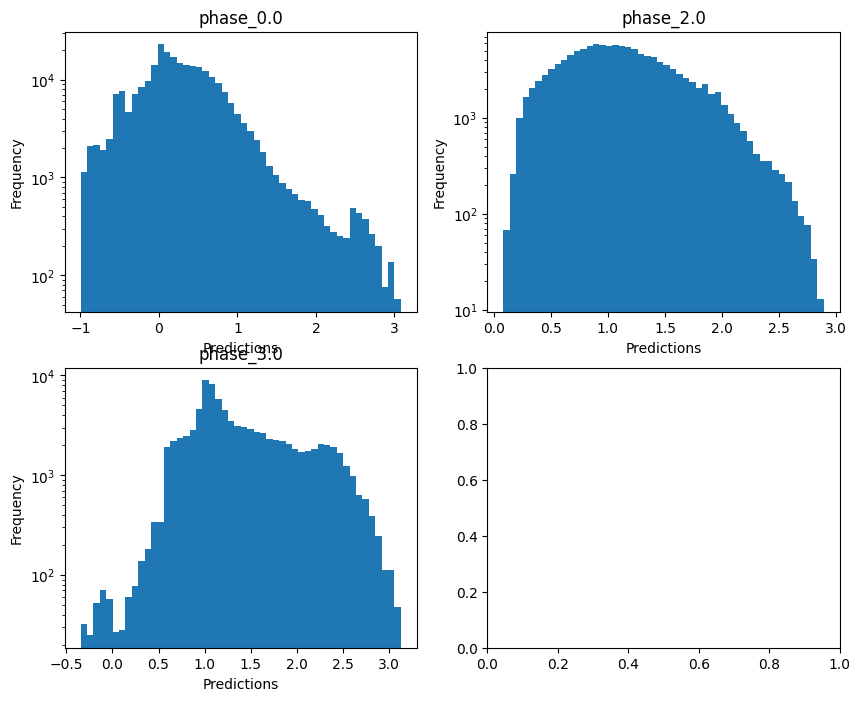

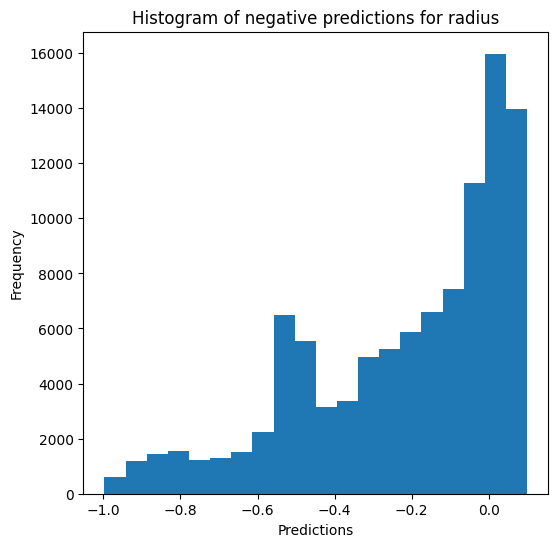

Saving predictions and results...


In [12]:
dt_evaluator.evaluate_Kfold_results(DecisionTreeRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=override, use_preds=use_preds, save=save, show=show, scaler_name=scaler_name)

### K-nearest neighbours

In [13]:
knn_evaluator = Model_evaluator("KNN", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


scale_power train data :
Performing K-fold...
Split 1 2 3 4 5 6 7 8 9 10 
Evaluating predictions...
no negative values

mass results for the phase category with a value of 0.0
  value range :  0.0999979840073621 - 298.5447575808816
  RVE :  0.992509635629161
  RMSE :  2.276431293951854
  MAE :  0.3304434733280586
  MedAE :  0.006519040392688025
  CORR :  0.9963578989313132
  MAX_ER :  99.43297165803614
  Percentiles : 
    75th percentile :  0.039438531049287295
    90th percentile :  0.2663525604389477
    95th percentile :  0.8462650119077767
    99th percentile :  7.583444058139987

mass results for the phase category with a value of 2.0
  value range :  0.6538581961218565 - 283.72102985530483
  RVE :  0.9994525162907033
  RMSE :  0.694800965011944
  MAE :  0.0833278572871728
  MedAE :  0.00295934458165803
  CORR :  0.9997262206887632
  MAX_ER :  37.48661252169403
  Percentiles : 
    75th percentile :  0.015661401906896355
    90th percentile :  0.07593821248982575
    95th percen

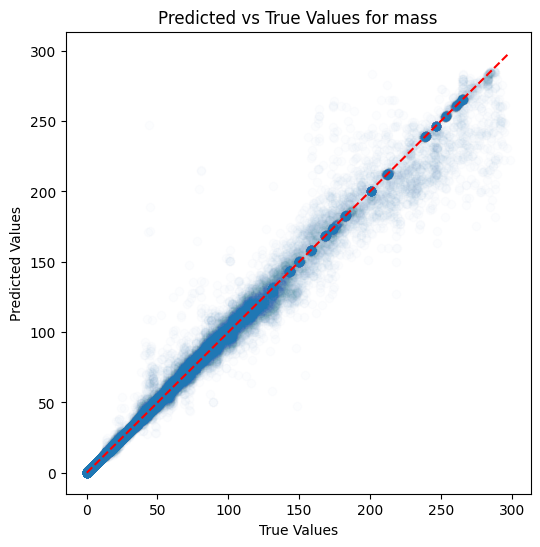

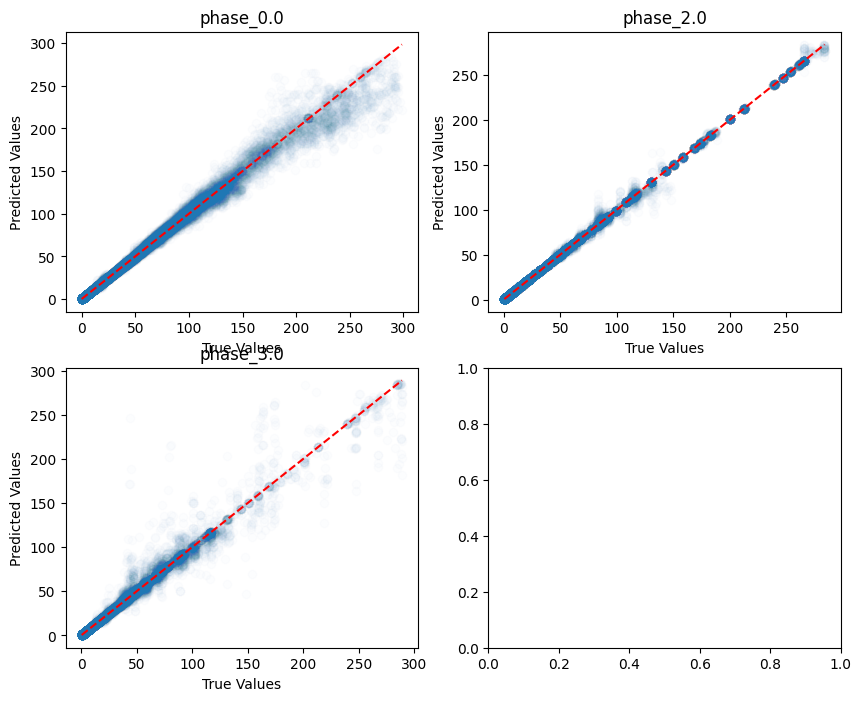

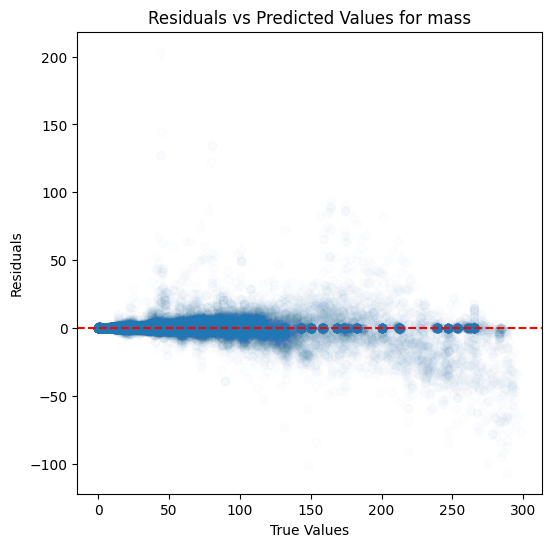

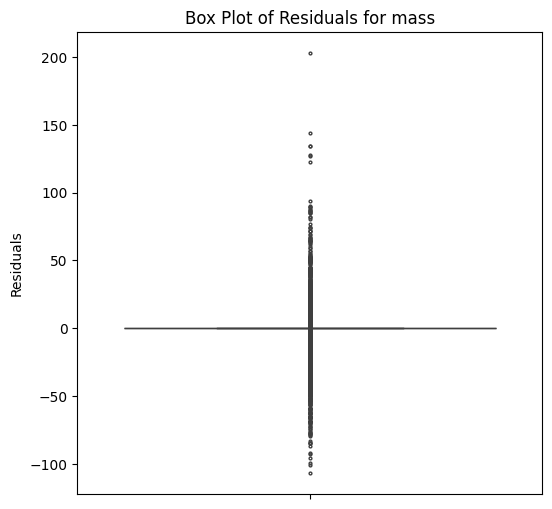

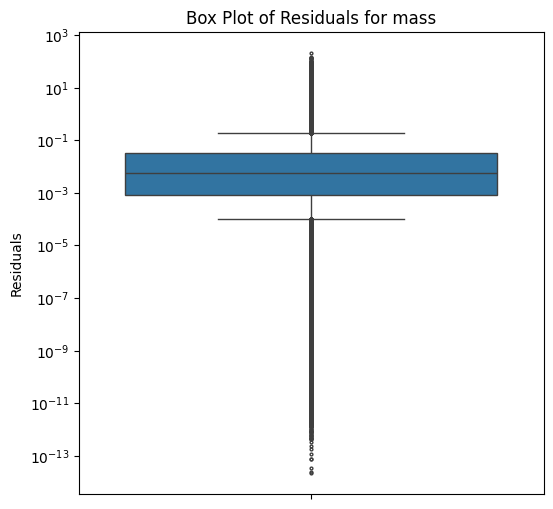

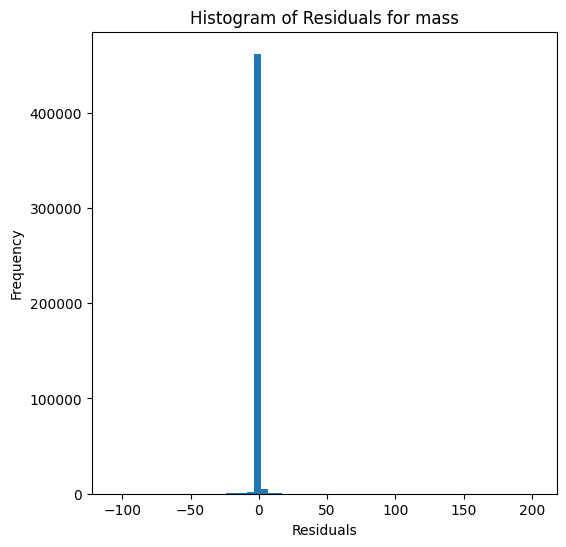

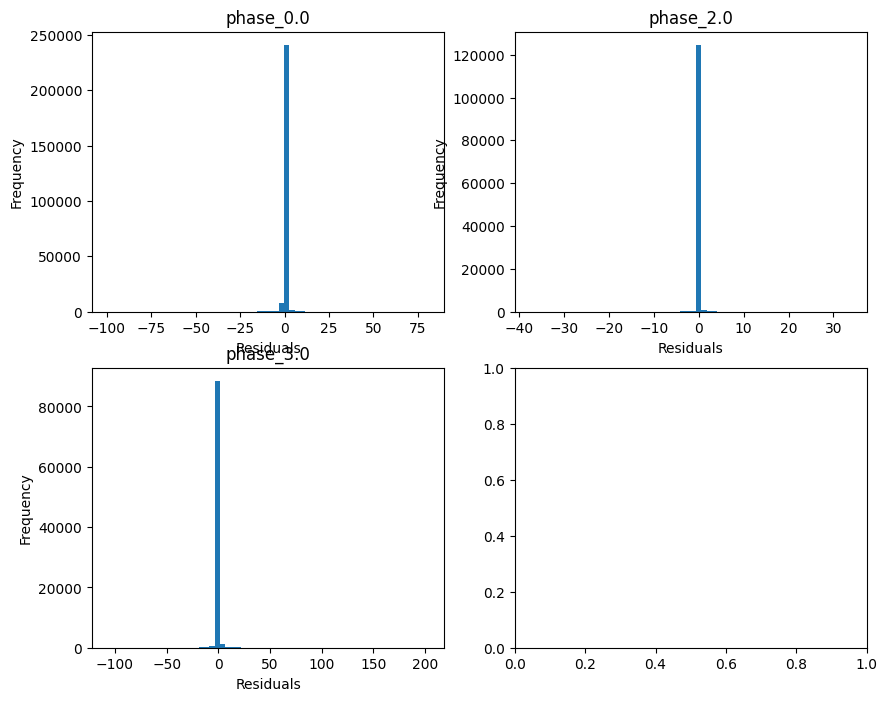

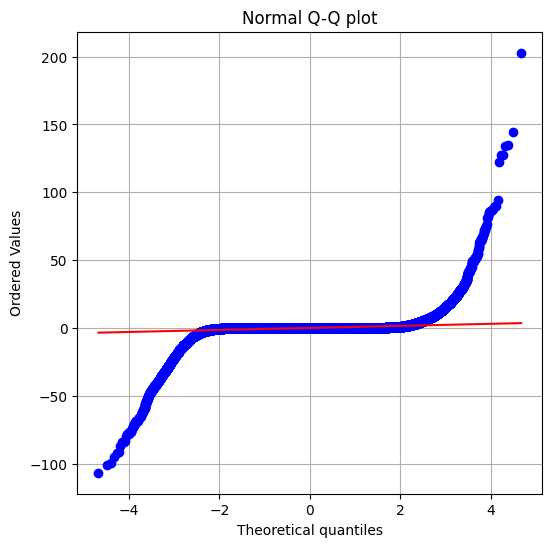

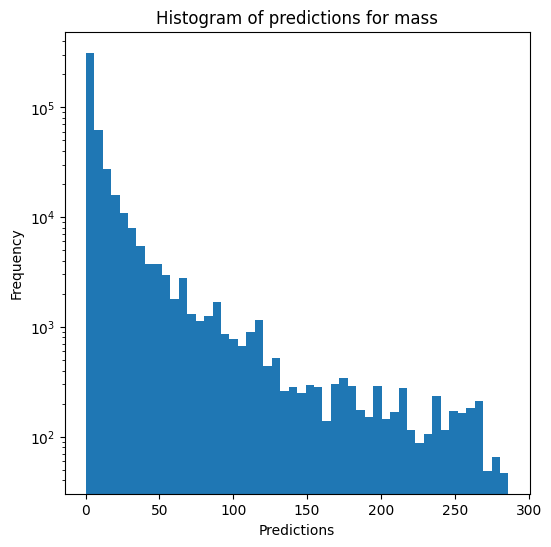

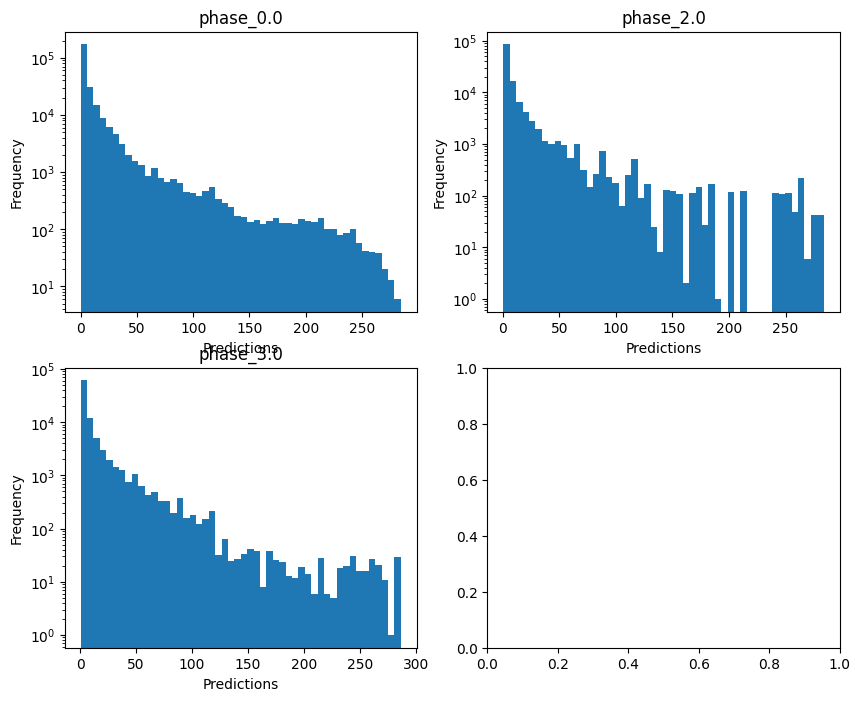


radius results for the phase category with a value of 0.0
  value range :  -0.9974628481553472 - 3.0827540579576227
  RVE :  0.9999123068864648
  RMSE :  0.005340540710008574
  MAE :  0.0032470063764030387
  MedAE :  0.0020855420957140297
  CORR :  0.9999561789209133
  MAX_ER :  0.14473630214320865
  Percentiles : 
    75th percentile :  0.004056918933337442
    90th percentile :  0.007155118201525237
    95th percentile :  0.009909781362505152
    99th percentile :  0.019859404541931833

radius results for the phase category with a value of 2.0
  value range :  0.0919862423867022 - 2.891706235288321
  RVE :  0.999862459528918
  RMSE :  0.005813083998399014
  MAE :  0.004154307523595139
  MedAE :  0.0029763471511607964
  CORR :  0.9999316286397391
  MAX_ER :  0.07723242145030396
  Percentiles : 
    75th percentile :  0.005639023907149654
    90th percentile :  0.009333977071985355
    95th percentile :  0.012065123879445104
    99th percentile :  0.018625241964355083

radius results 

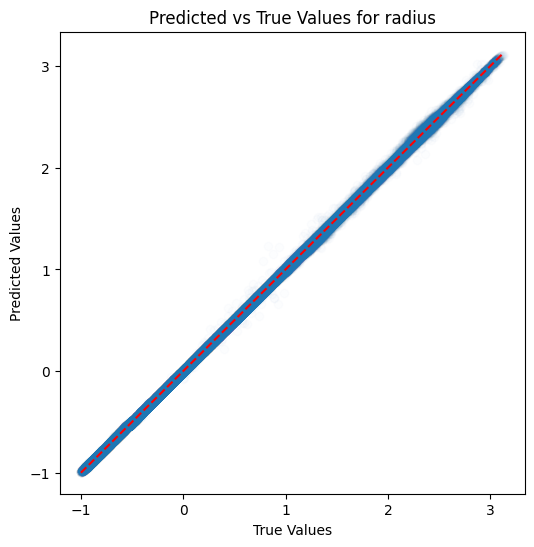

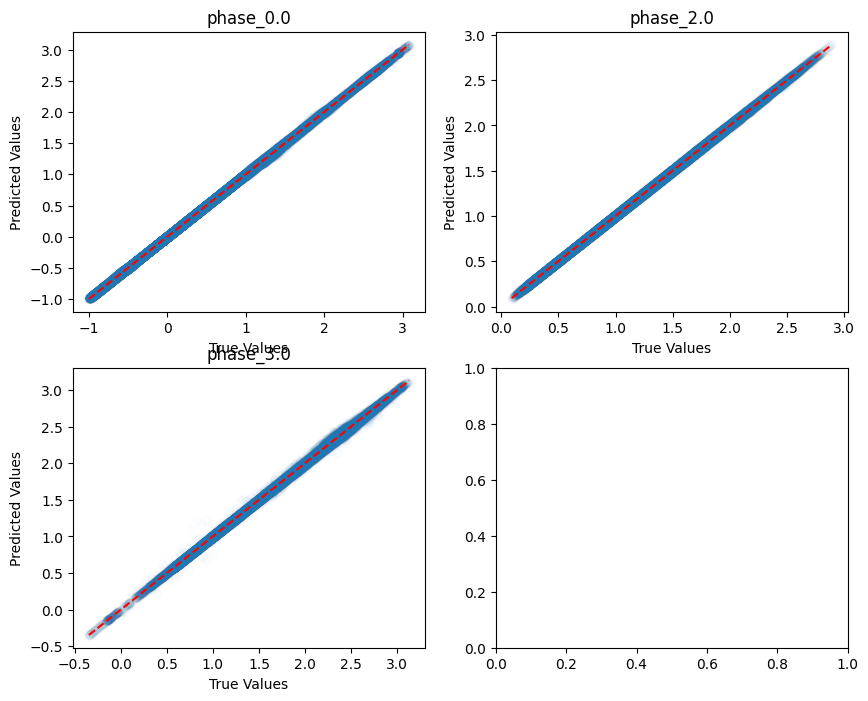

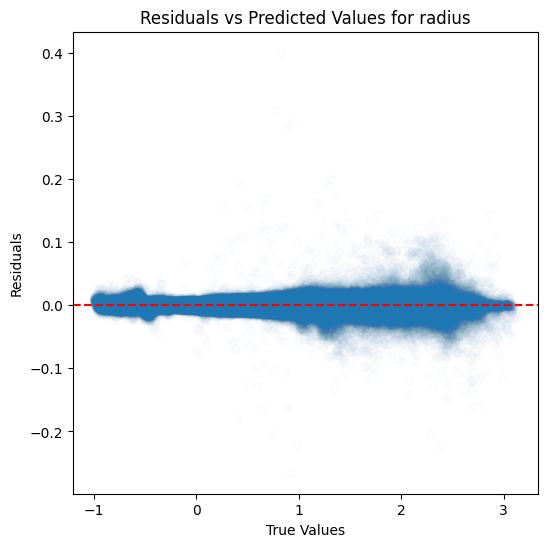

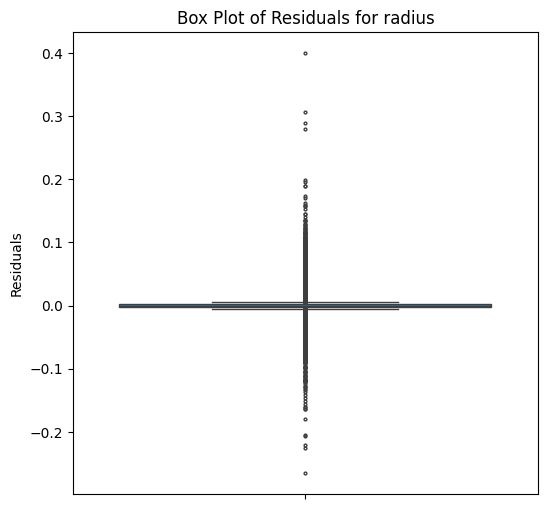

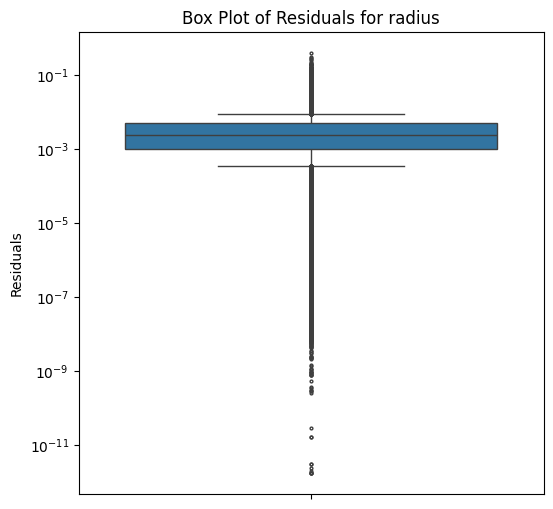

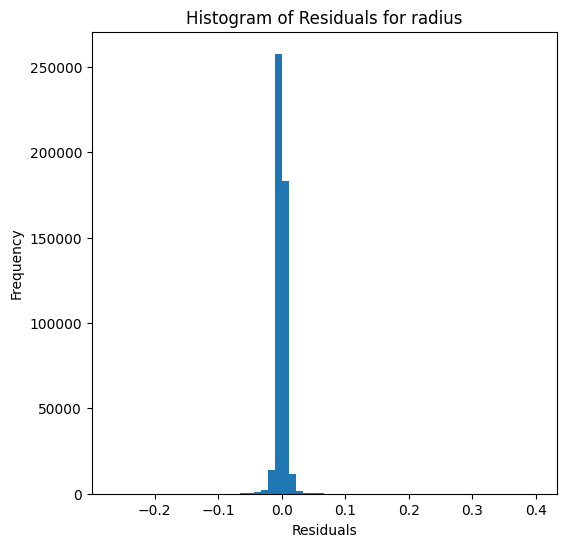

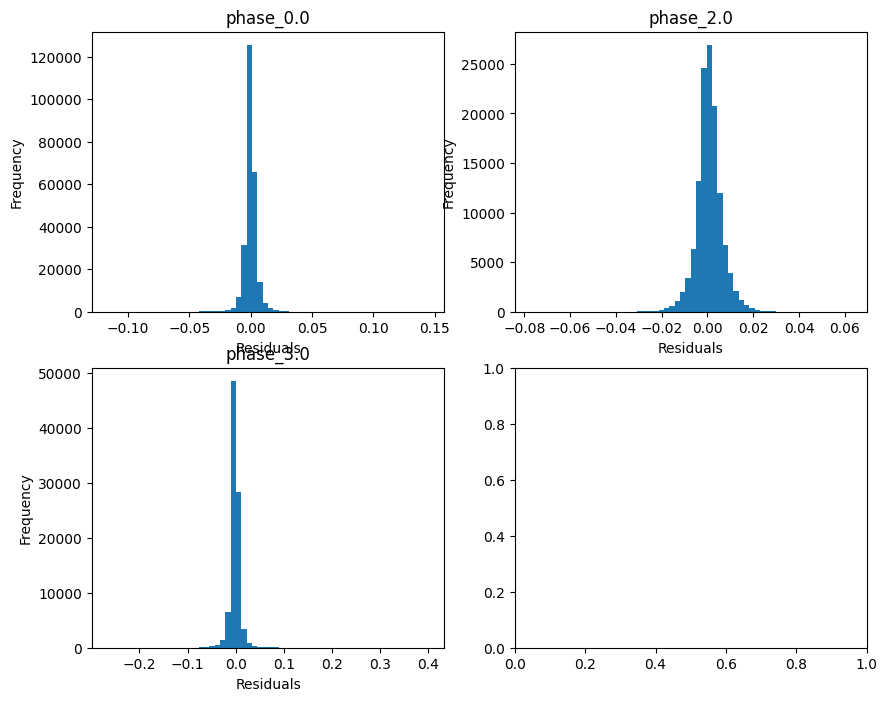

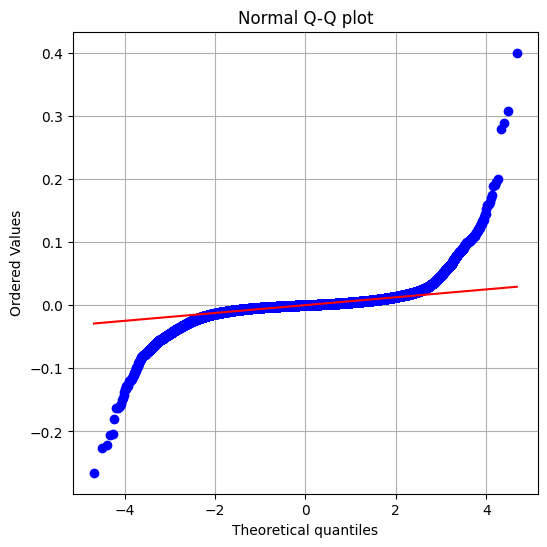

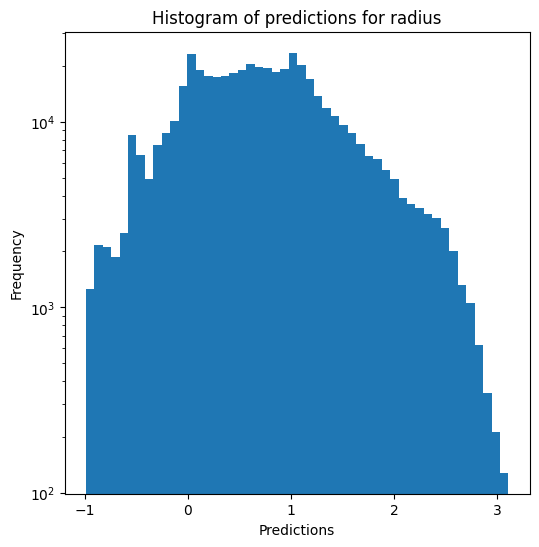

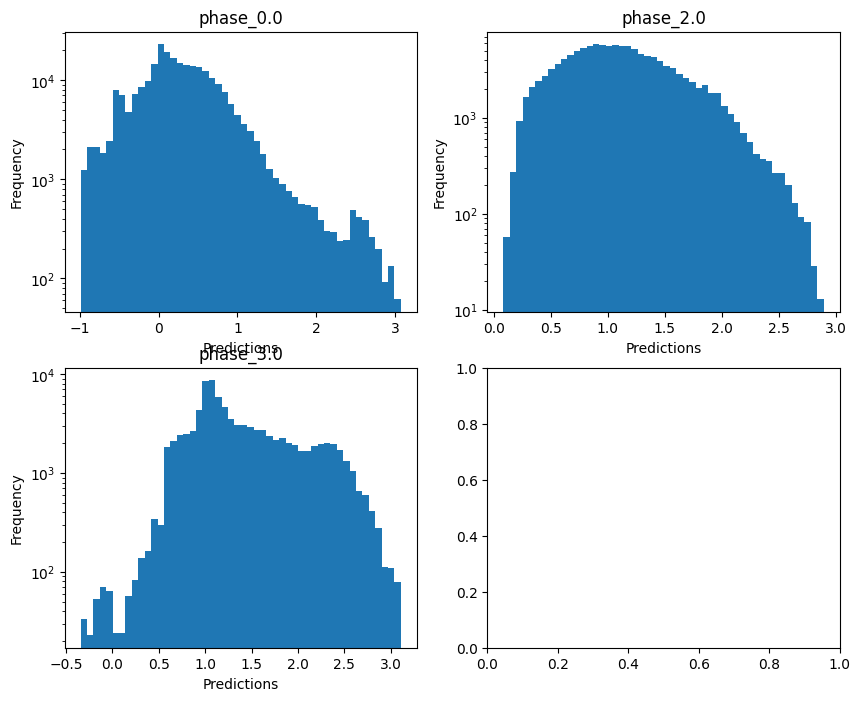

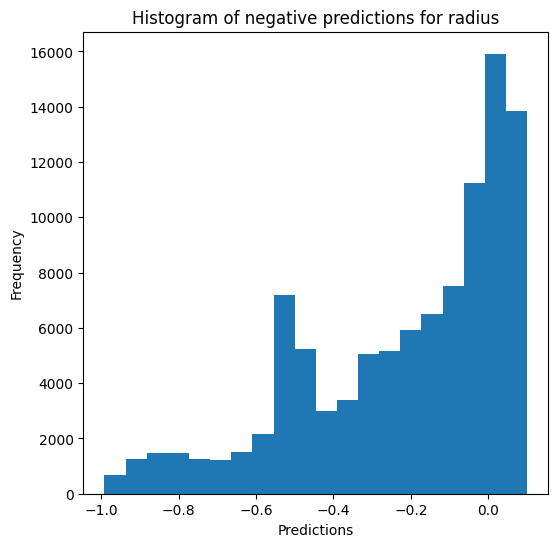

Saving predictions and results...


In [14]:
knn_evaluator.evaluate_Kfold_results(KNeighborsRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=override, use_preds=use_preds, save=save, show=show, scaler_name=scaler_name)

### Random forests

In [15]:
rf_evaluator = Model_evaluator("random_forest", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


scale_power train data :
Performing K-fold...
Split 1 2 3 4 5 6 7 8 9 10 
Evaluating predictions...

mass results for the phase category with a value of 0.0
  value range :  0.0999979840073621 - 298.5447575808816
  RVE :  0.9973698735789078
  RMSE :  1.3490523508997752
  MAE :  0.16768106850568817
  MedAE :  0.003571053734099605
  CORR :  0.9986859998912465
  MAX_ER :  82.71790938826177
  Percentiles : 
    75th percentile :  0.01656473781608314
    90th percentile :  0.10920318616557947
    95th percentile :  0.4158823641960116
    99th percentile :  3.6170590707857864

mass results for the phase category with a value of 2.0
  value range :  0.6538581961218565 - 283.72102985530483
  RVE :  0.9997462583266511
  RMSE :  0.473051809939149
  MAE :  0.059443301942151465
  MedAE :  0.00405243204316541
  CORR :  0.9998737882353769
  MAX_ER :  24.036445456532164
  Percentiles : 
    75th percentile :  0.010619659702182926
    90th percentile :  0.02572571149832586
    95th percentile :  0.07

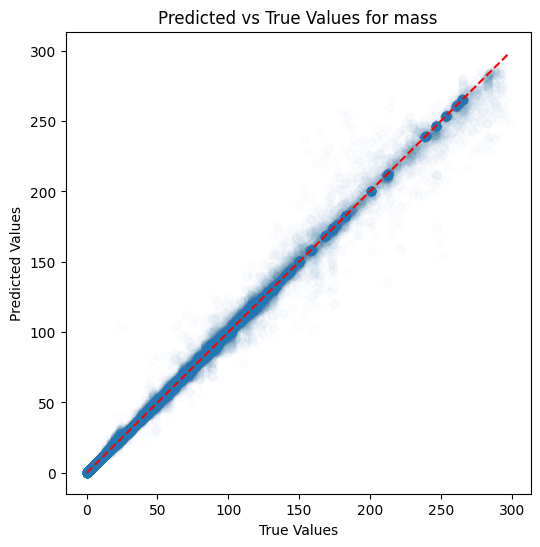

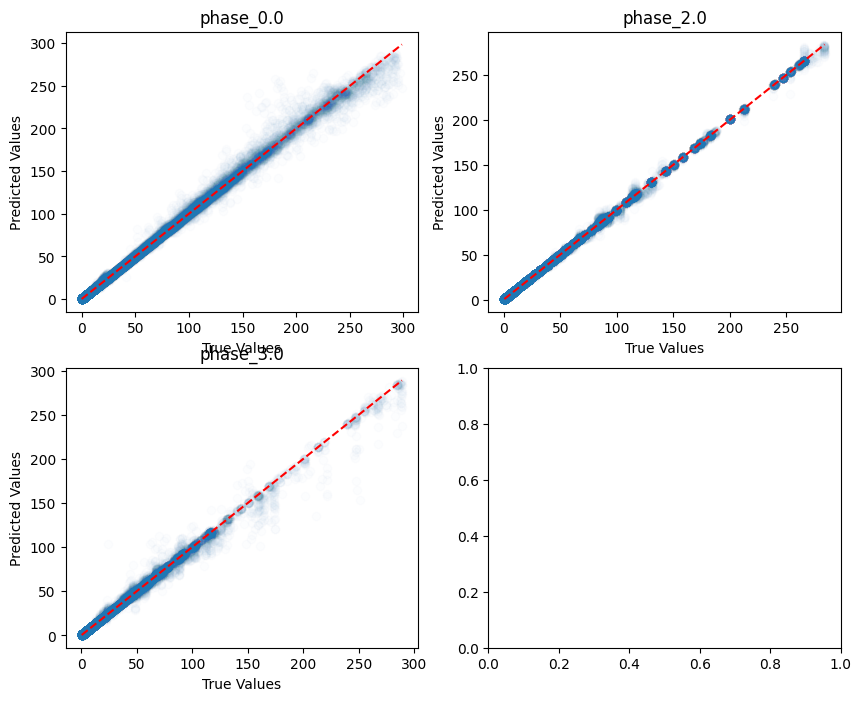

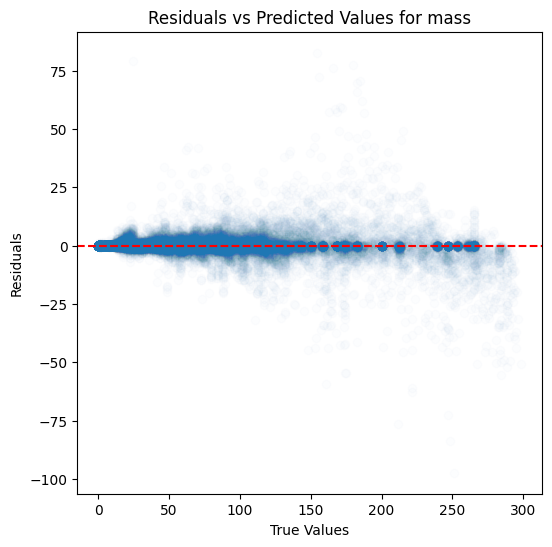

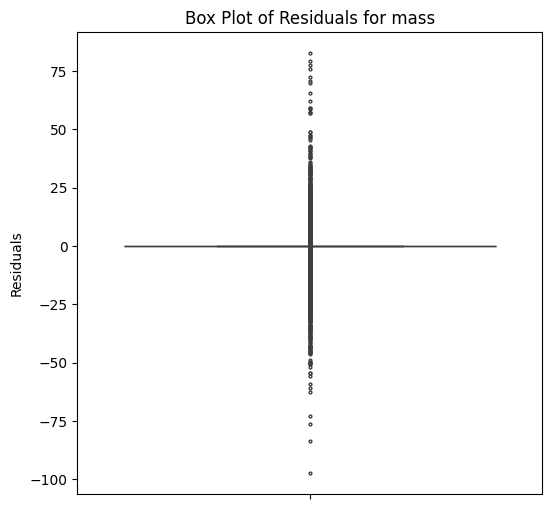

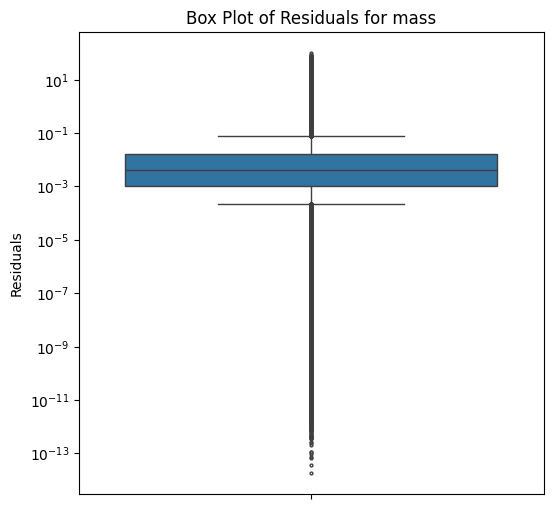

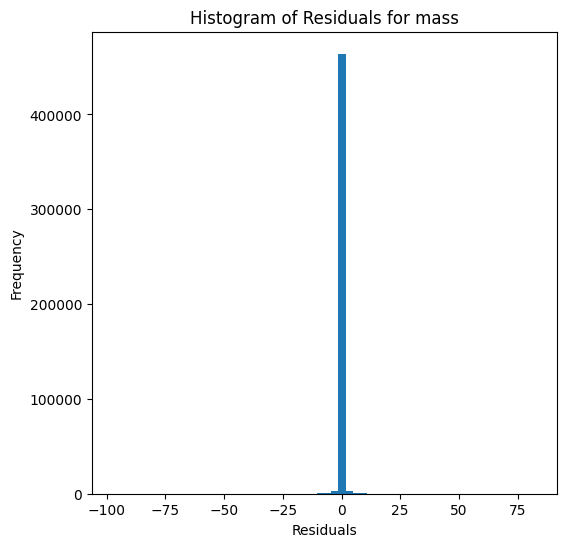

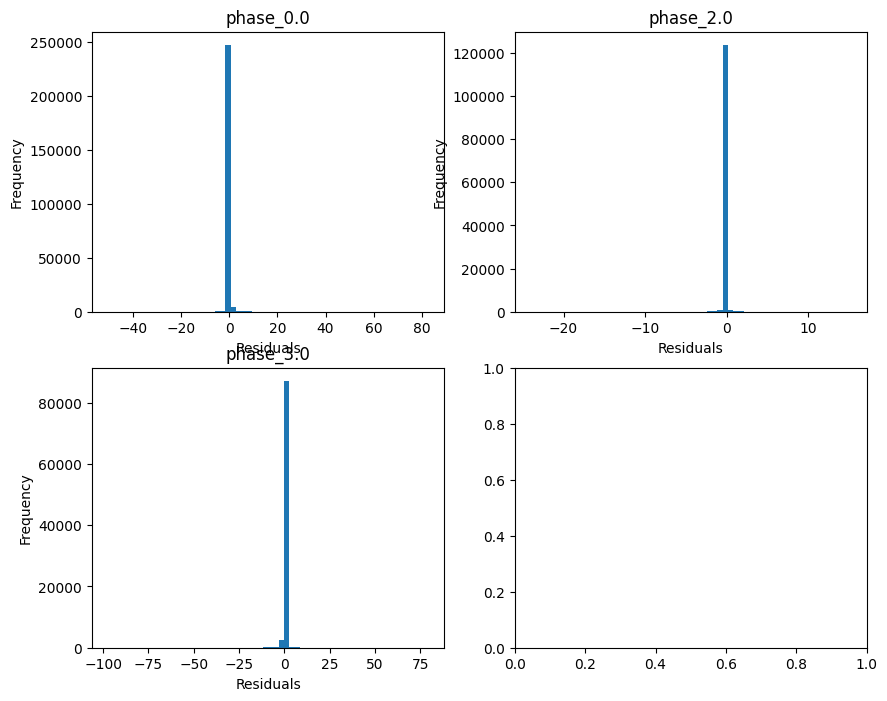

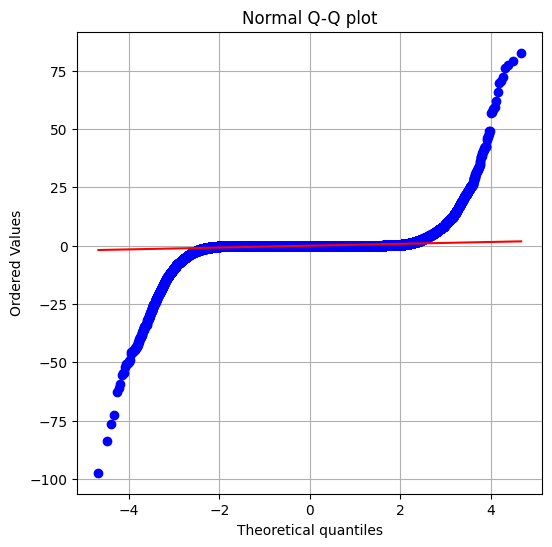

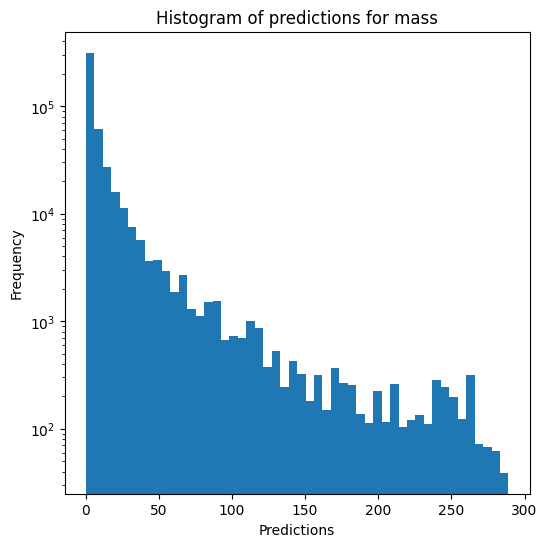

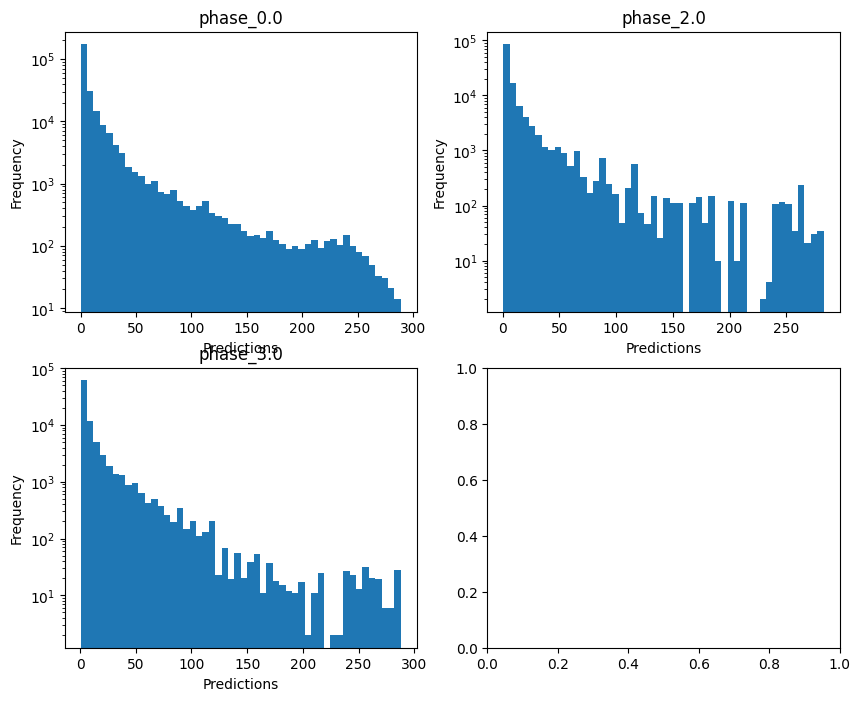

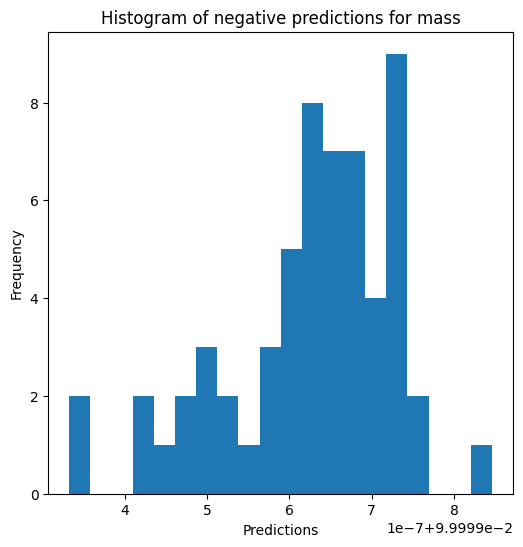


radius results for the phase category with a value of 0.0
  value range :  -0.9974628481553472 - 3.0827540579576227
  RVE :  0.9999461523890759
  RMSE :  0.004184914738187784
  MAE :  0.00209326759569358
  MedAE :  0.0010243606340871042
  CORR :  0.9999731174889579
  MAX_ER :  0.35522662037456554
  Percentiles : 
    75th percentile :  0.0023329925280478857
    90th percentile :  0.004845241767614042
    95th percentile :  0.007579043625636039
    99th percentile :  0.01649081280251721

radius results for the phase category with a value of 2.0
  value range :  0.0919862423867022 - 2.891706235288321
  RVE :  0.9999346689729685
  RMSE :  0.004004237262663704
  MAE :  0.0026241638046232995
  MedAE :  0.0016847939522549593
  CORR :  0.9999678785983874
  MAX_ER :  0.0759834113331701
  Percentiles : 
    75th percentile :  0.003499455367407922
    90th percentile :  0.006075606711367777
    95th percentile :  0.008146487326903085
    99th percentile :  0.014051029147831079

radius results f

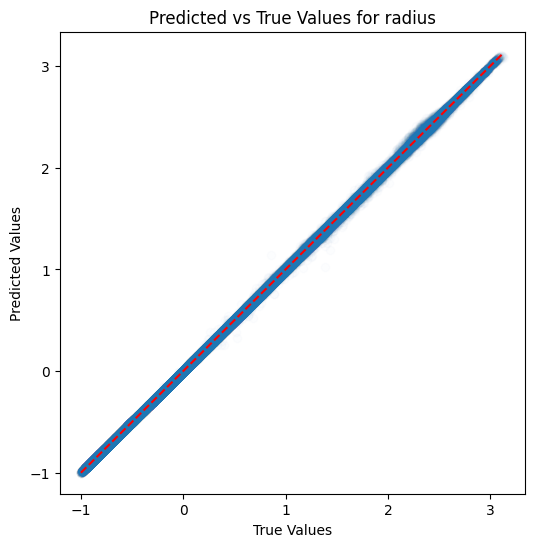

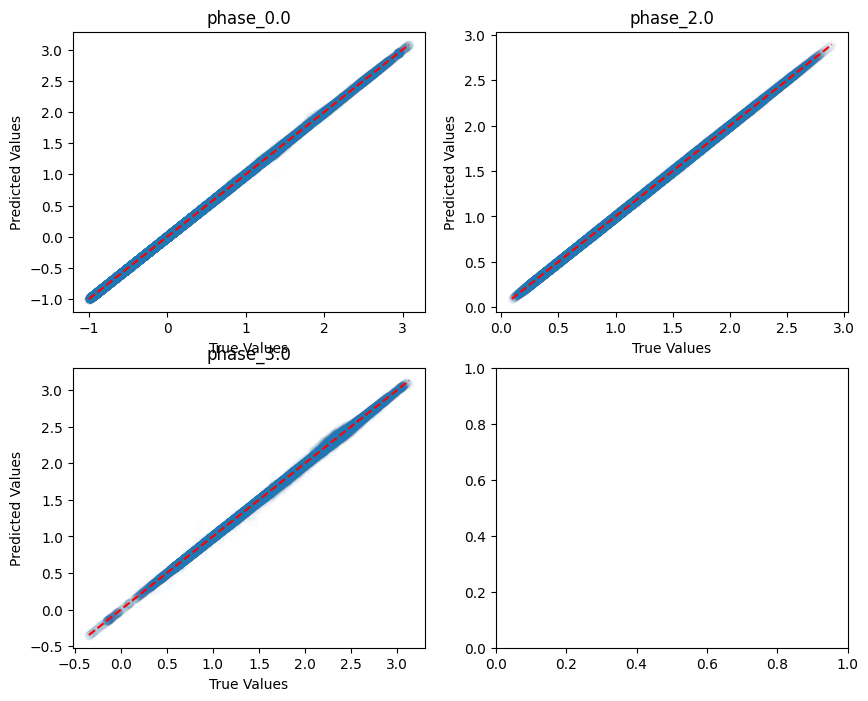

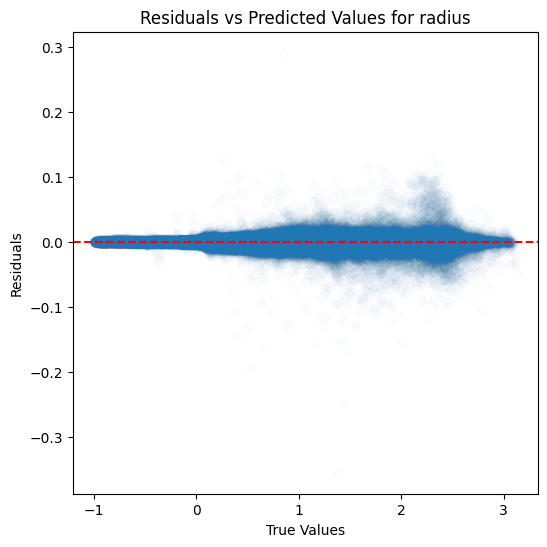

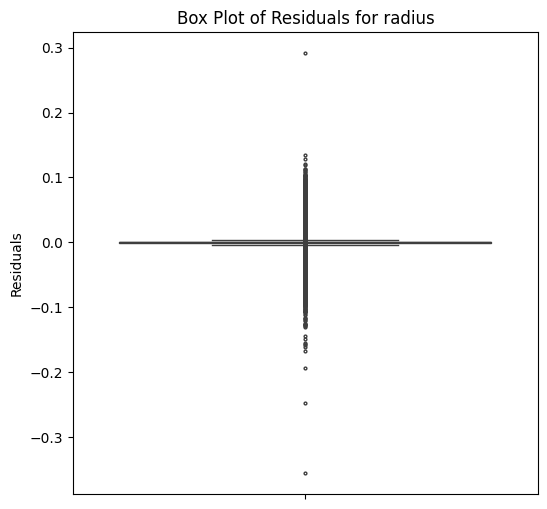

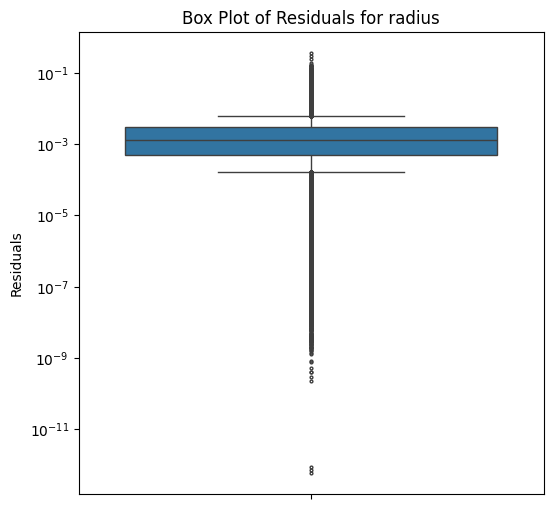

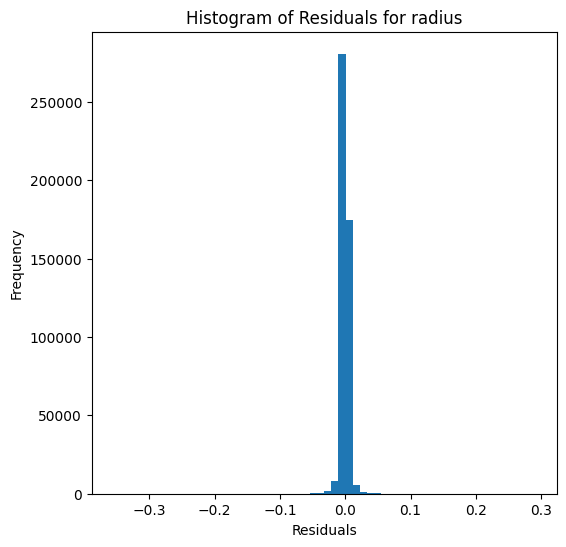

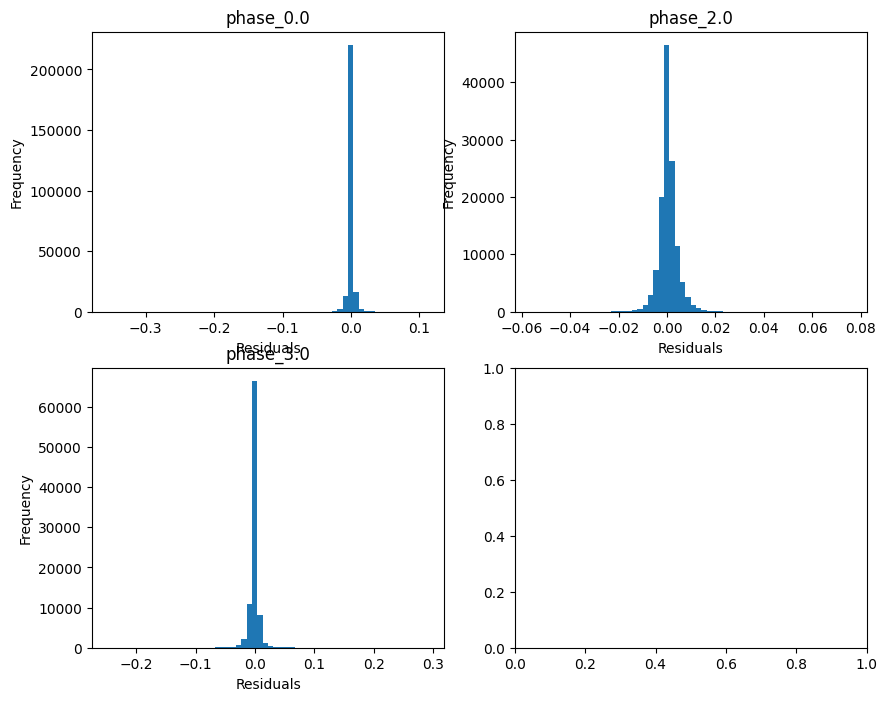

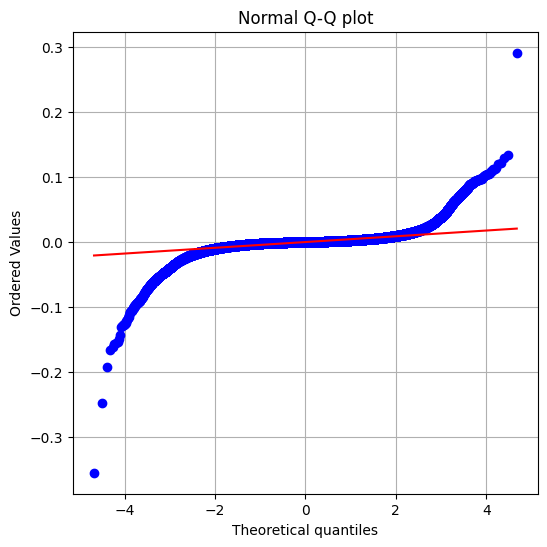

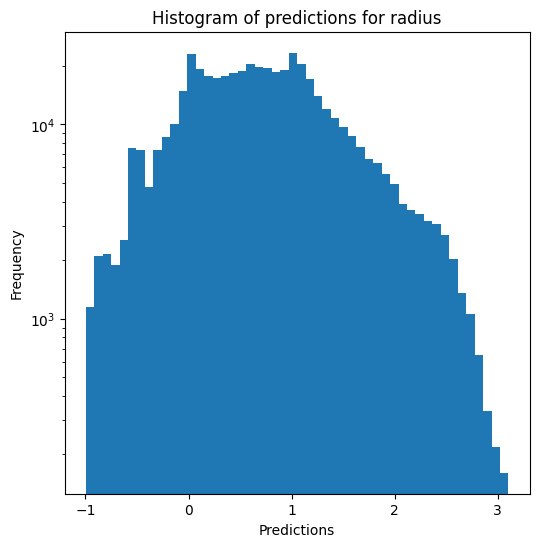

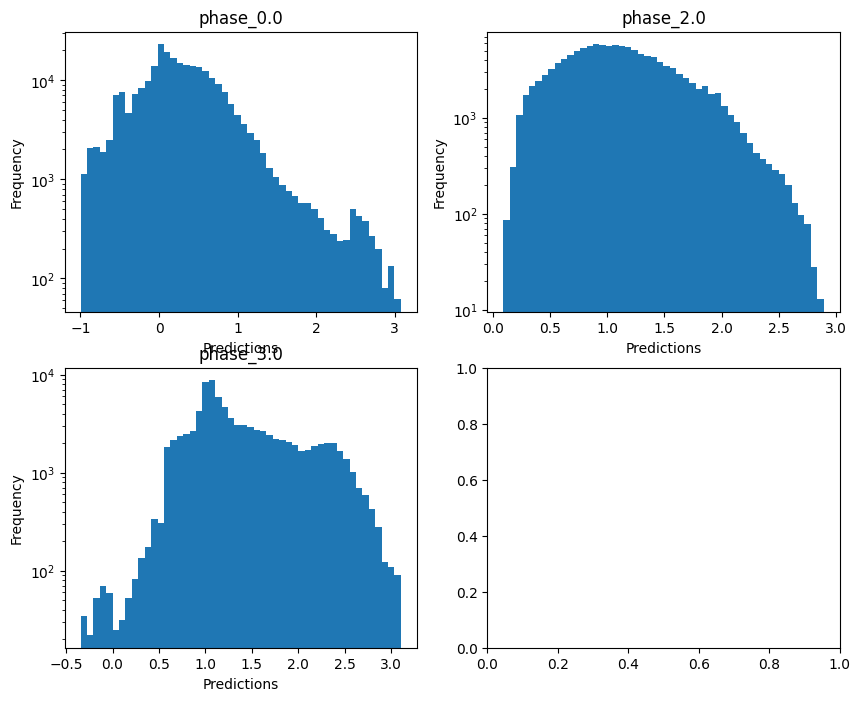

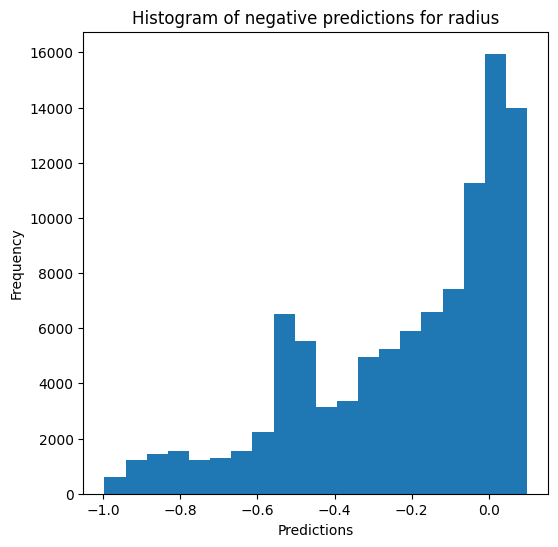

Saving predictions and results...


In [16]:
rf_evaluator.evaluate_Kfold_results(RandomForestRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=override, use_preds=use_preds, save=save, show=show, scaler_name=scaler_name, n_jobs=5)
# average depth de 44-46

### XGBoost

In [17]:
xgb_evaluator = Model_evaluator("xgboost", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


scale_power train data :
Performing K-fold...
Split 1 2 3 4 5 6 7 8 9 10 
Evaluating predictions...

mass results for the phase category with a value of 0.0
  value range :  0.0999979840073621 - 298.5447575808816
  RVE :  0.9910987312588692
  RMSE :  2.4814124721700055
  MAE :  0.6770023659900075
  MedAE :  0.1267936515820881
  CORR :  0.9955610707335958
  MAX_ER :  75.48444222351264
  Percentiles : 
    75th percentile :  0.3883500504020383
    90th percentile :  1.2957648046229508
    95th percentile :  2.709098574480243
    99th percentile :  10.872019043130127

mass results for the phase category with a value of 2.0
  value range :  0.6538581961218565 - 283.72102985530483
  RVE :  0.9988417935213513
  RMSE :  1.0107839826404676
  MAE :  0.29703938184770073
  MedAE :  0.07024103435696705
  CORR :  0.9994585536328132
  MAX_ER :  41.74161390163965
  Percentiles : 
    75th percentile :  0.15709466847949694
    90th percentile :  0.539963539437732
    95th percentile :  1.349611433790

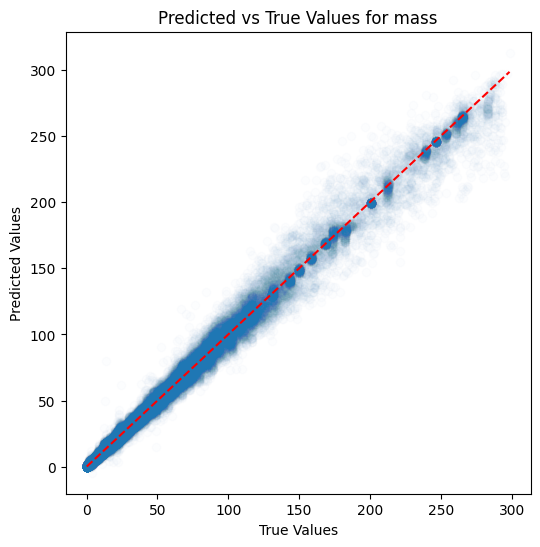

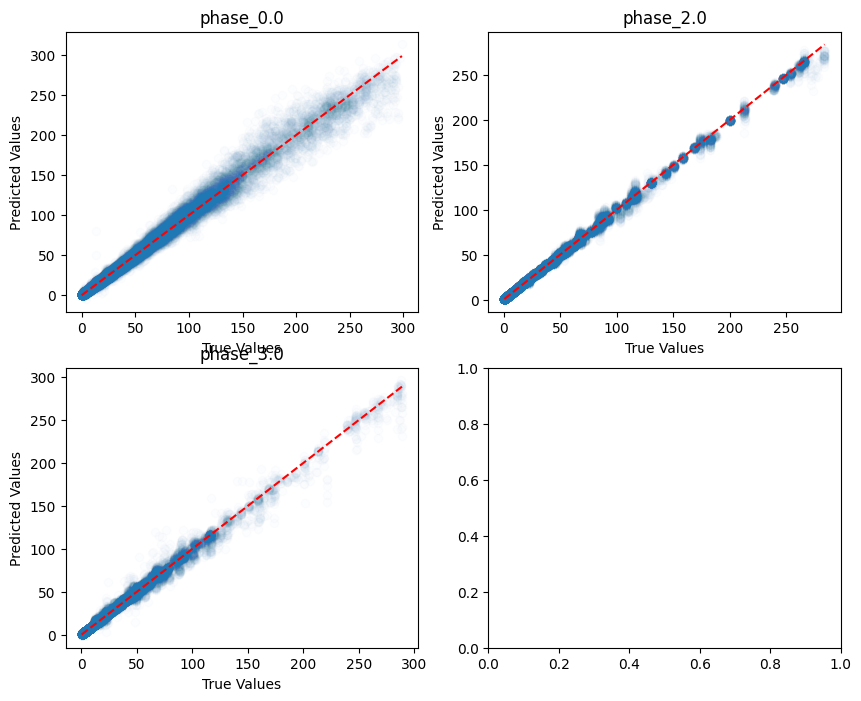

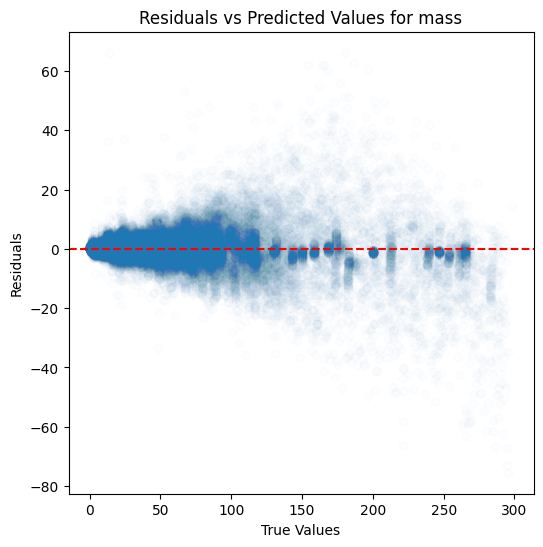

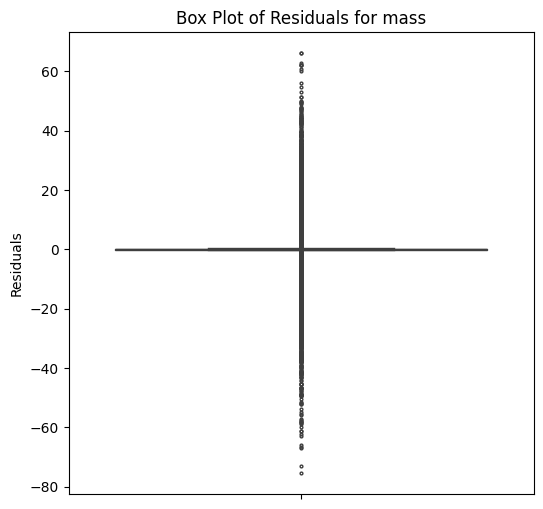

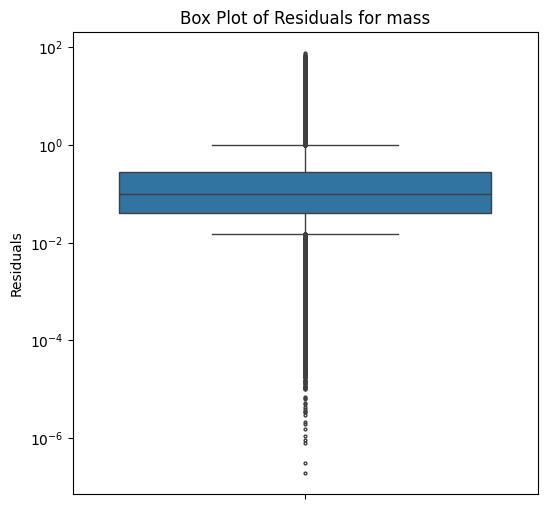

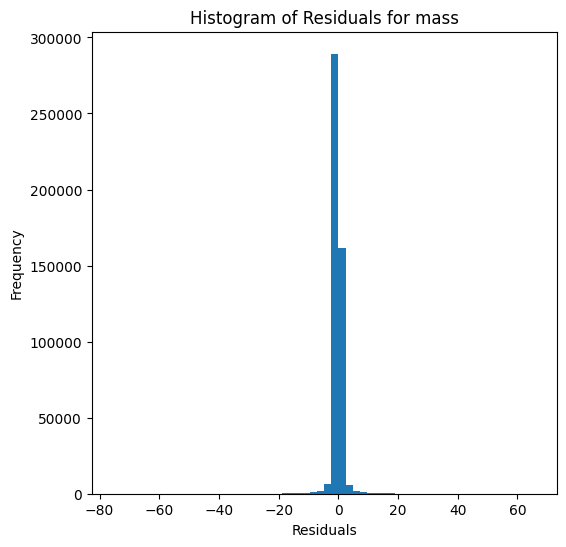

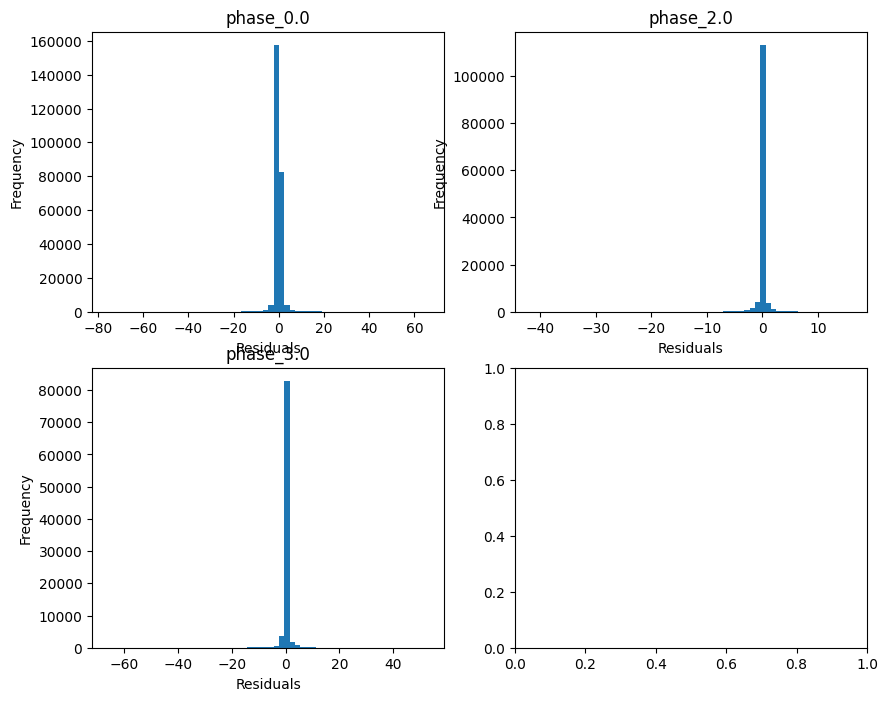

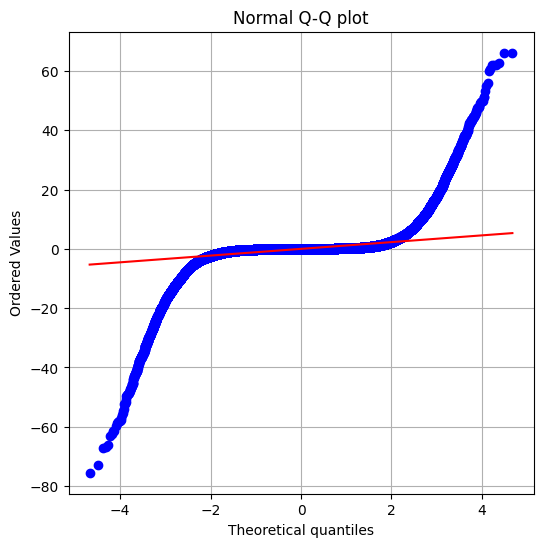

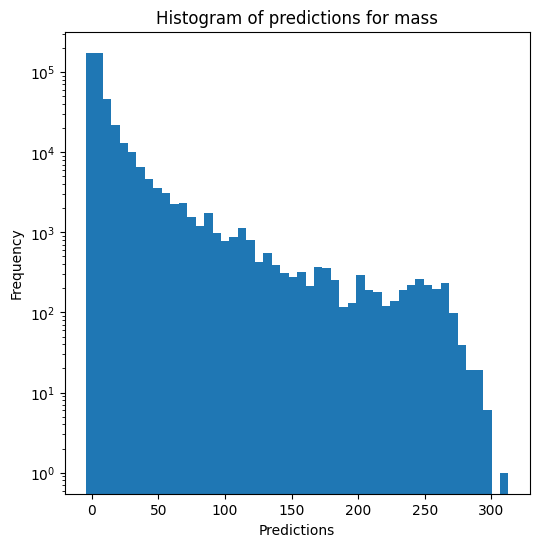

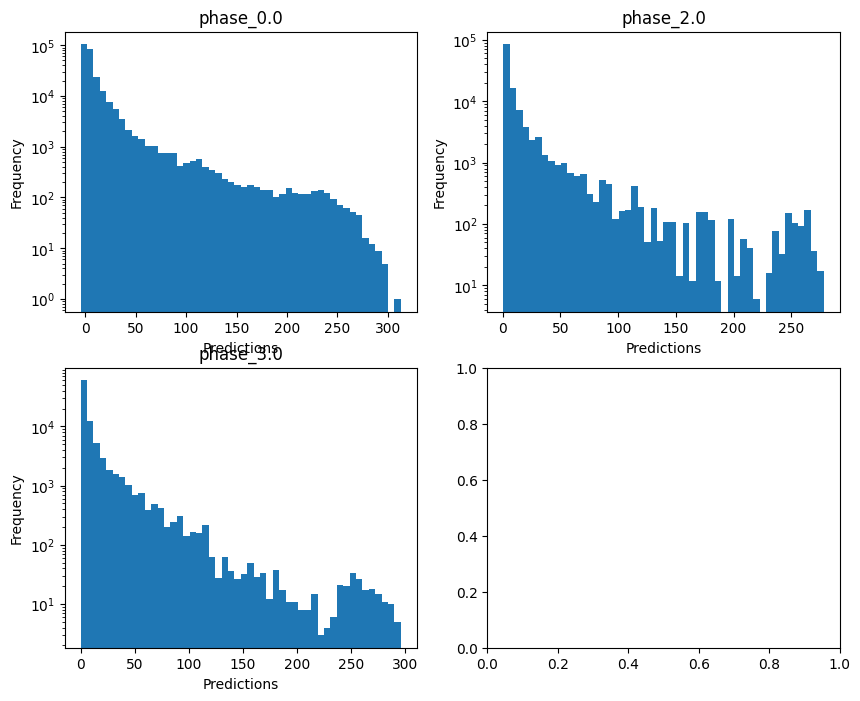

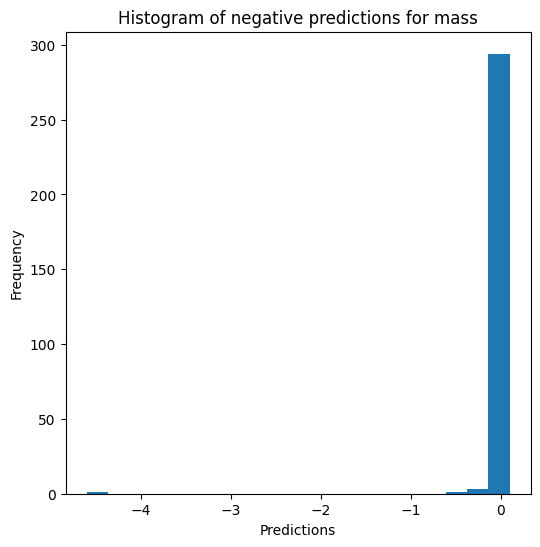


radius results for the phase category with a value of 0.0
  value range :  -0.9974628481553472 - 3.0827540579576227
  RVE :  0.9994434633557444
  RMSE :  0.013453885317189652
  MAE :  0.009889859469221449
  MedAE :  0.007456182471675038
  CORR :  0.9997217276059344
  MAX_ER :  0.14995242551436805
  Percentiles : 
    75th percentile :  0.013547970653927356
    90th percentile :  0.021470055899873327
    95th percentile :  0.027507610530642927
    99th percentile :  0.04193835848501641

radius results for the phase category with a value of 2.0
  value range :  0.0919862423867022 - 2.891706235288321
  RVE :  0.999205779158902
  RMSE :  0.013844147853230356
  MAE :  0.01081876267026667
  MedAE :  0.0088802648706654
  CORR :  0.9996033393483618
  MAX_ER :  0.08179401702331068
  Percentiles : 
    75th percentile :  0.015393341203222888
    90th percentile :  0.022586968335280445
    95th percentile :  0.0274852175359744
    99th percentile :  0.03835646565417285

radius results for the ph

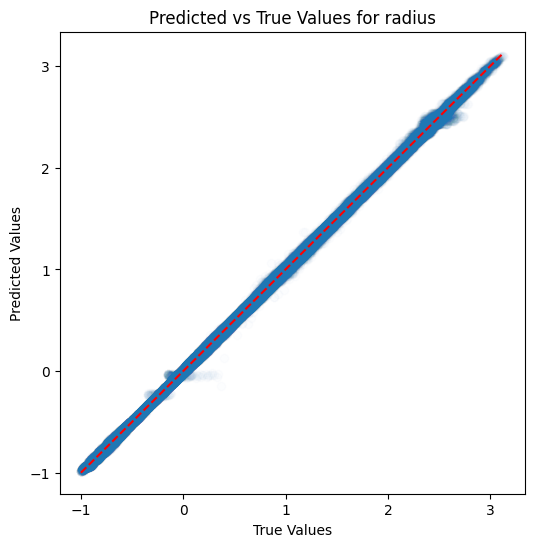

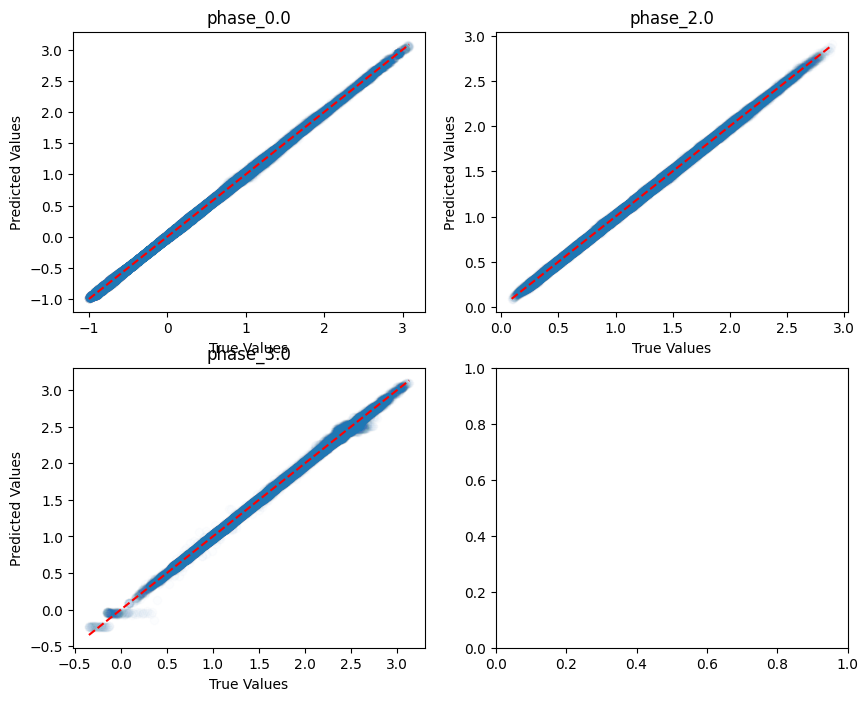

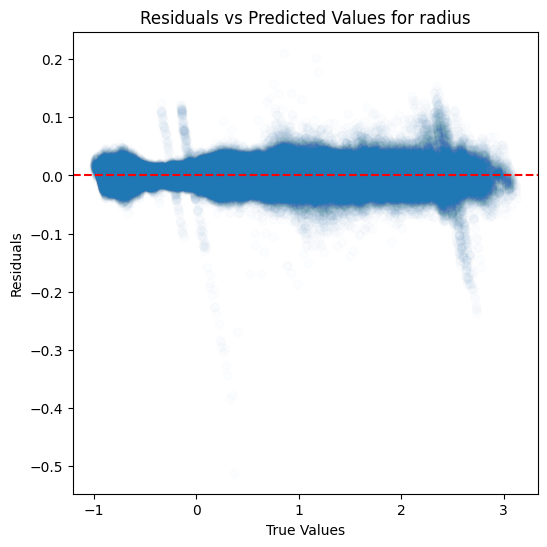

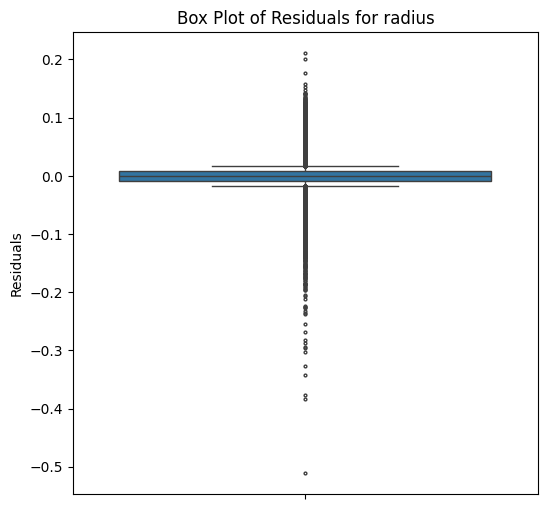

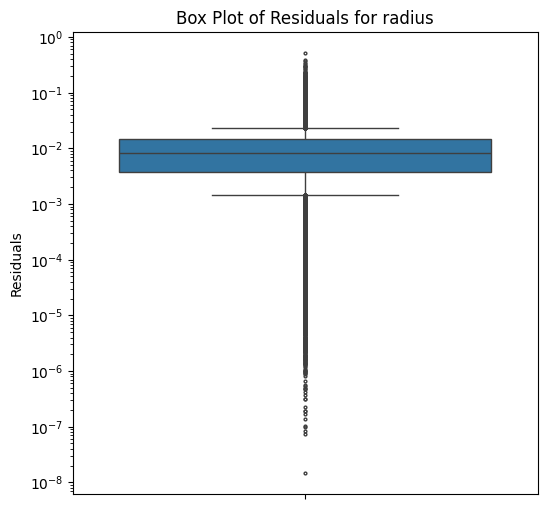

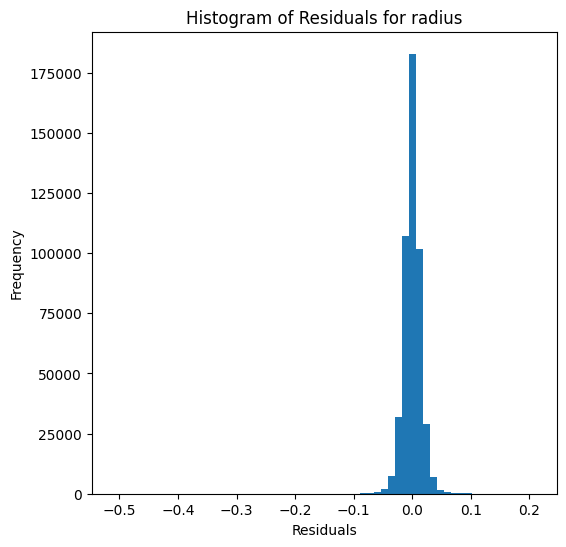

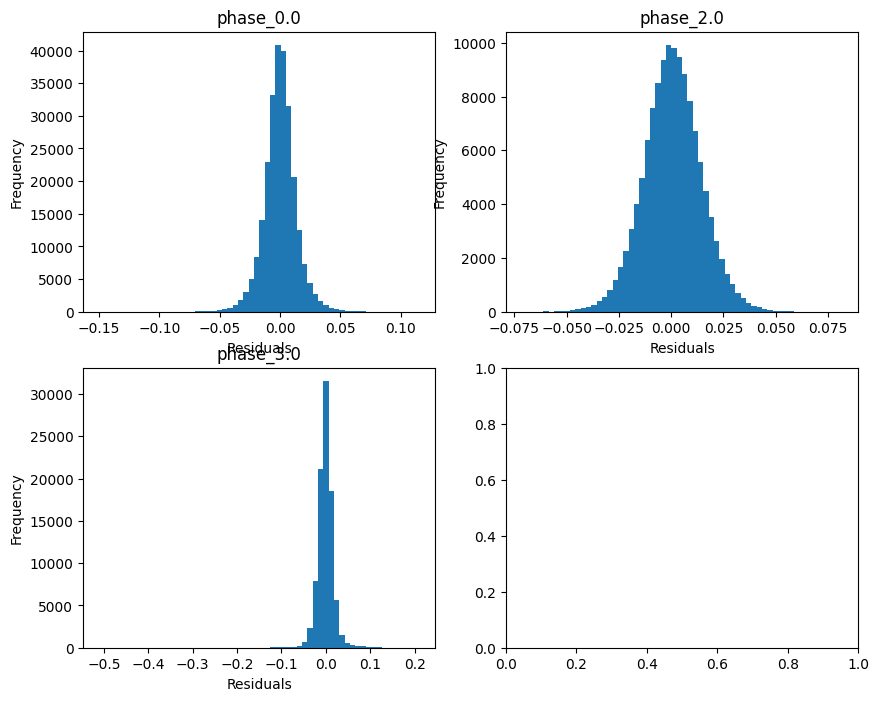

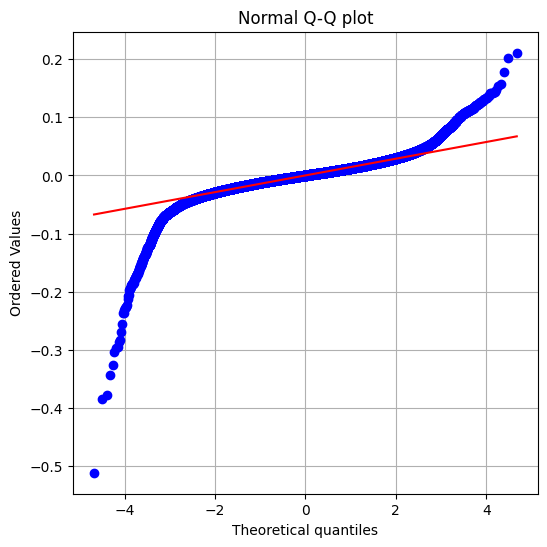

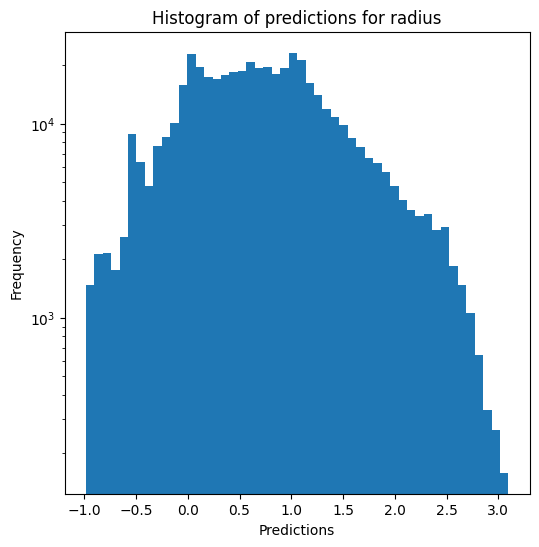

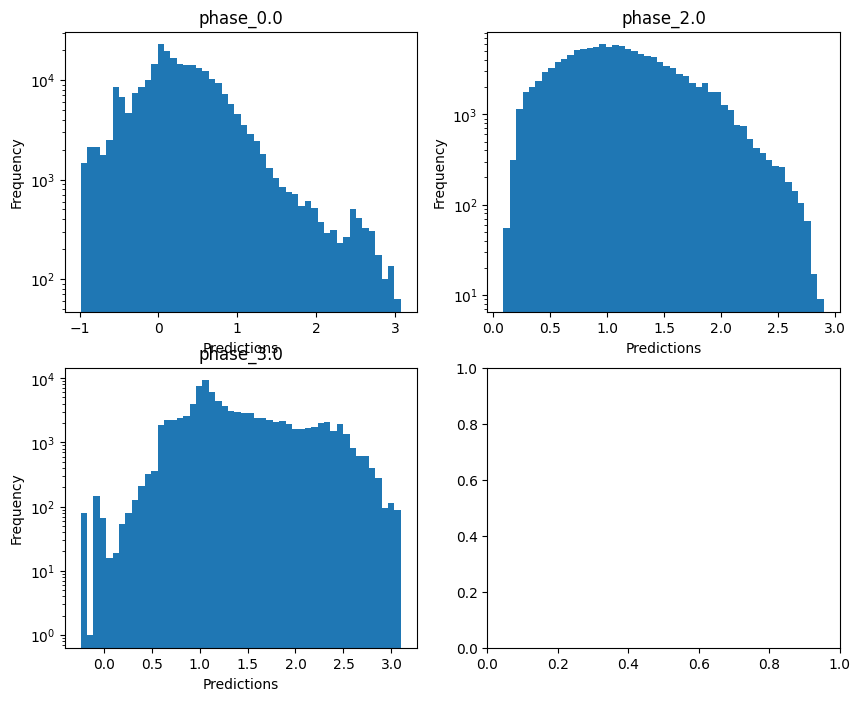

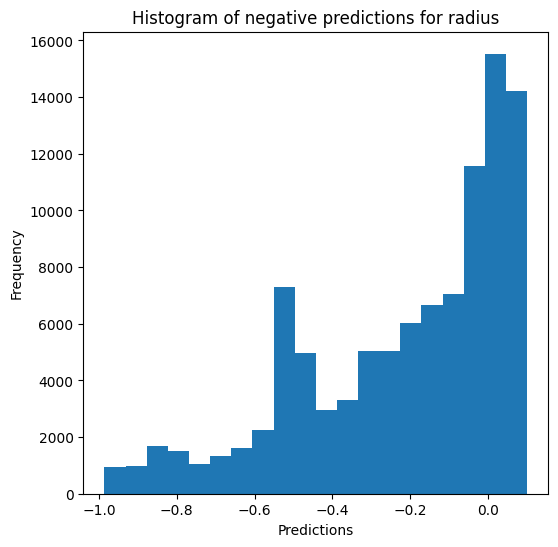

Saving predictions and results...


In [18]:
xgb_evaluator.evaluate_Kfold_results(XGBRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=override, use_preds=use_preds, save=save, show=show, scaler_name=scaler_name, n_jobs=5)

### Multi-layer perceptron

In [19]:
mlp_evaluator = Model_evaluator("mlp", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


scale_power train data :
Performing K-fold...
Split 1 

c:\Users\antoi\Code\unif\MA2\thesis\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


1.079896493533903
2 

c:\Users\antoi\Code\unif\MA2\thesis\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


1.2576079330314442
3 

...

1.1113404214987281
4 

c:\Users\antoi\Code\unif\MA2\thesis\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


1.2487572465489583
5 

c:\Users\antoi\Code\unif\MA2\thesis\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


0.9701625369649618

Evaluating predictions...

mass results for the phase category with a value of 0.0
  value range :  0.0999979840073621 - 298.5447575808816
  RVE :  0.9928570663963947
  RMSE :  2.2288914242473097
  MAE :  0.6211203455562102
  MedAE :  0.14607775874371634
  CORR :  0.9964366880967247
  MAX_ER :  56.716794041469996
  Percentiles : 
    75th percentile :  0.38002165583730746
    90th percentile :  1.0750756793665808
    95th percentile :  2.636801715583358
    99th percentile :  8.242951869069445

mass results for the phase category with a value of 2.0
  value range :  0.6538581961218565 - 283.72102985530483
  RVE :  0.9930856960543955
  RMSE :  2.4834356899344074
  MAE :  0.5818643691007755
  MedAE :  0.1739090938082235
  CORR :  0.9972029218783641
  MAX_ER :  81.54789287715704
  Percentiles : 
    75th percentile :  0.3422773123554309
    90th percentile :  0.7864812731228256
    95th percentile :  1.9774262112525907
    99th percentile :  8.156639381113173

mass res

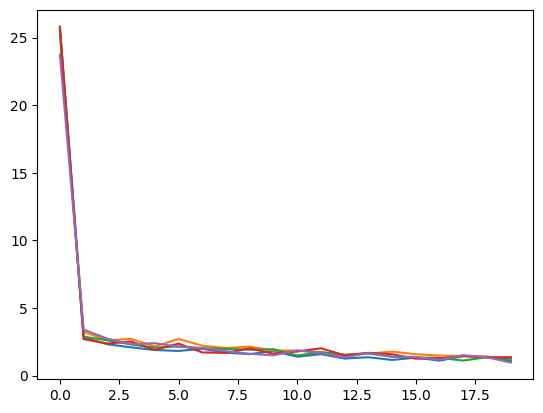

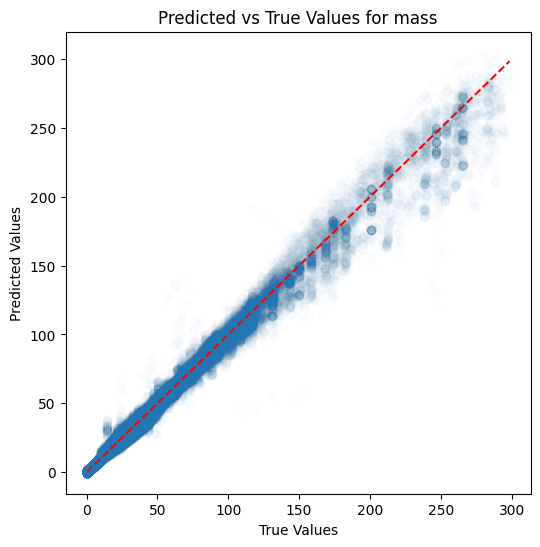

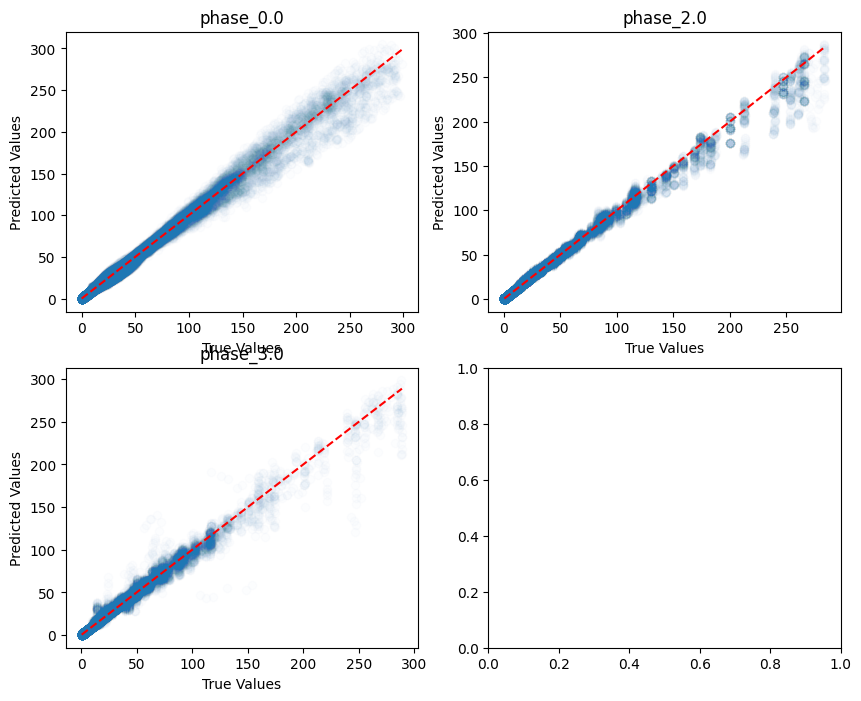

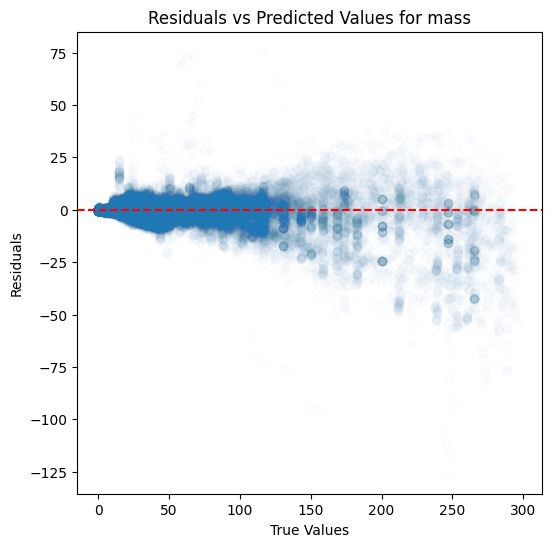

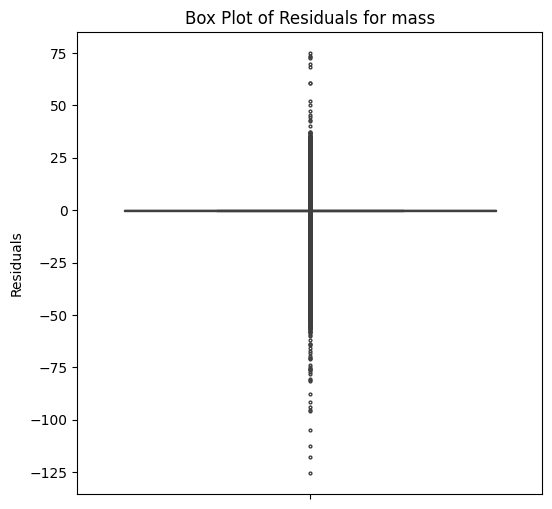

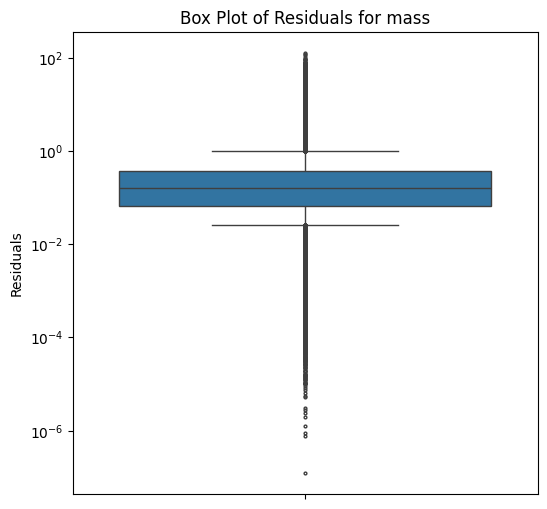

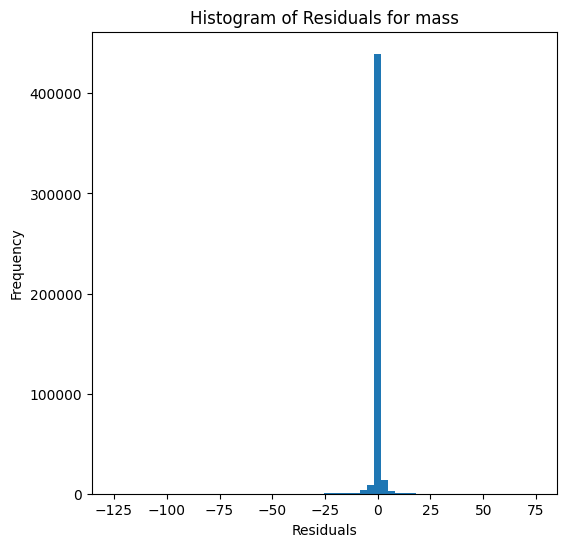

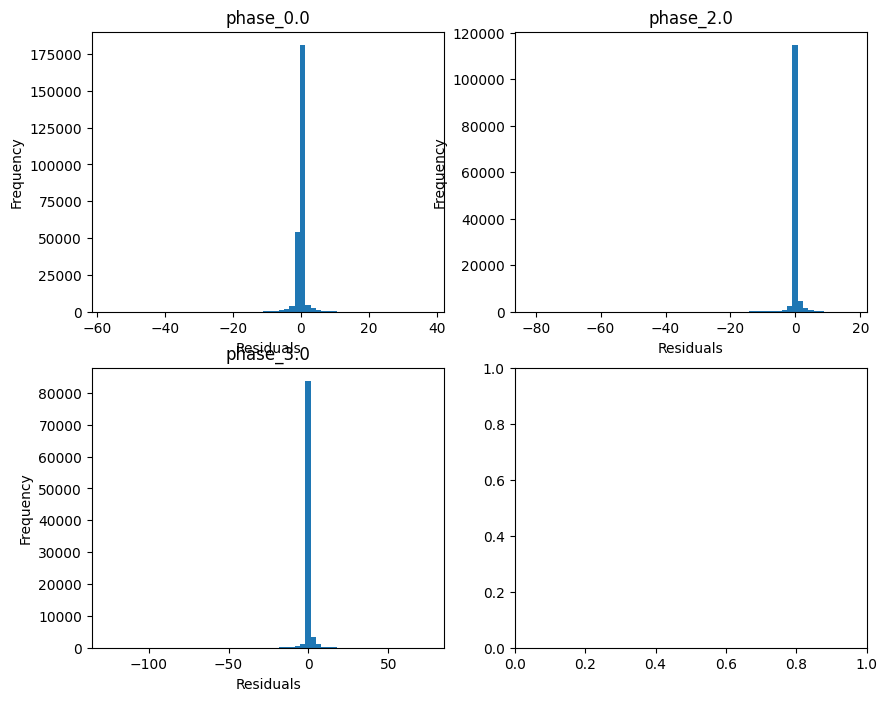

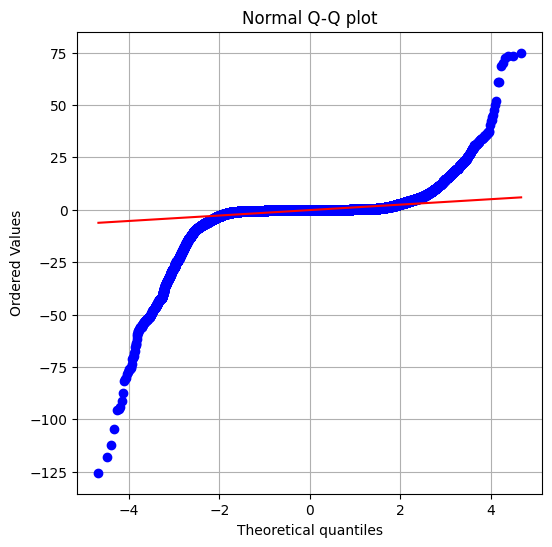

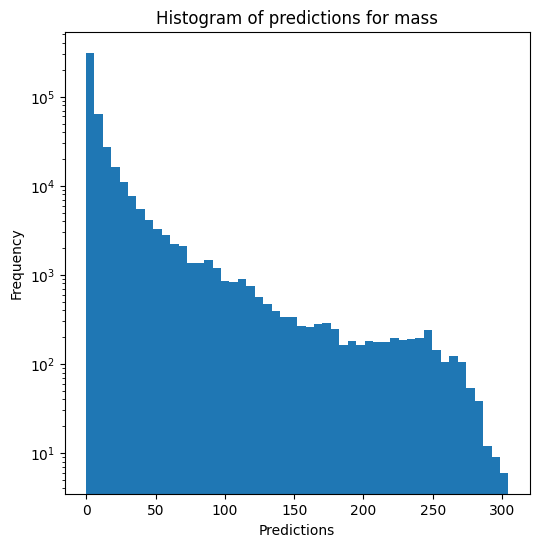

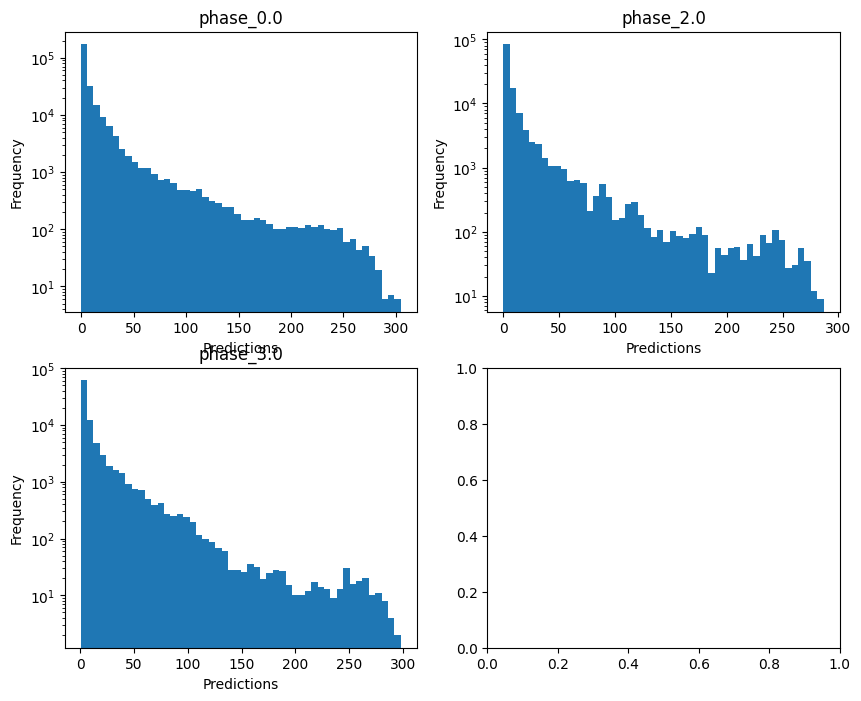

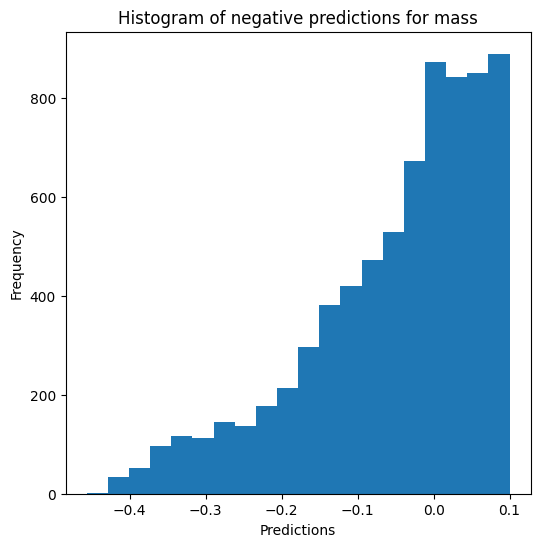


radius results for the phase category with a value of 0.0
  value range :  -0.9974628481553472 - 3.0827540579576227
  RVE :  0.980163499329707
  RMSE :  0.08071442210697755
  MAE :  0.060075808079727934
  MedAE :  0.04581839281024788
  CORR :  0.9901030410939038
  MAX_ER :  0.796268148735567
  Percentiles : 
    75th percentile :  0.08231457197128907
    90th percentile :  0.13208788717458225
    95th percentile :  0.16616463271712925
    99th percentile :  0.23995074574154468

radius results for the phase category with a value of 2.0
  value range :  0.0919862423867022 - 2.891706235288321
  RVE :  0.9739959193110057
  RMSE :  0.0794847109917624
  MAE :  0.059384977350308156
  MedAE :  0.046936127341419054
  CORR :  0.9875459308173362
  MAX_ER :  0.5932607007034139
  Percentiles : 
    75th percentile :  0.08251063342391152
    90th percentile :  0.1244559054973271
    95th percentile :  0.15478747743485596
    99th percentile :  0.23135292562766774

radius results for the phase categ

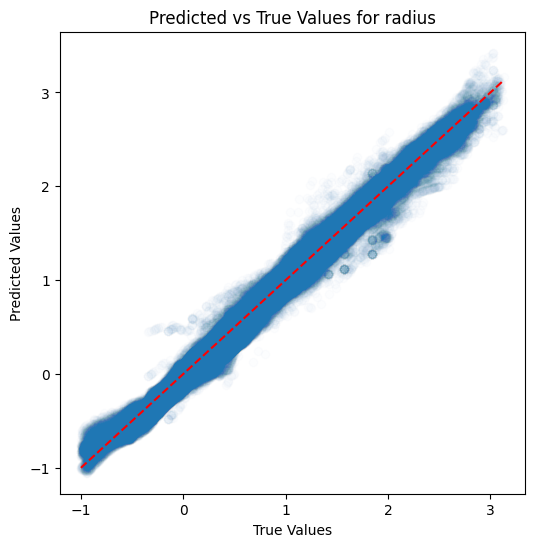

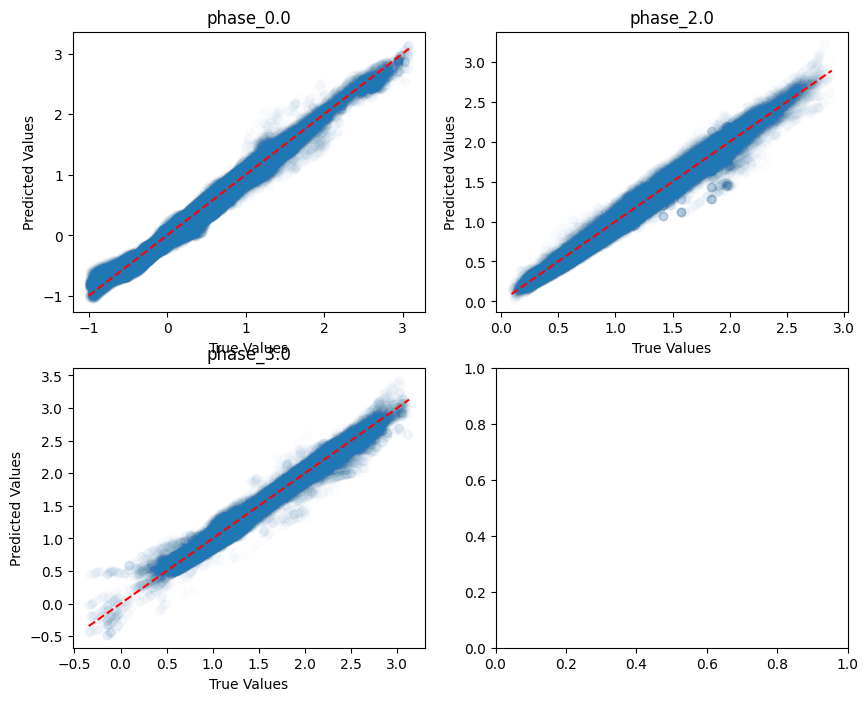

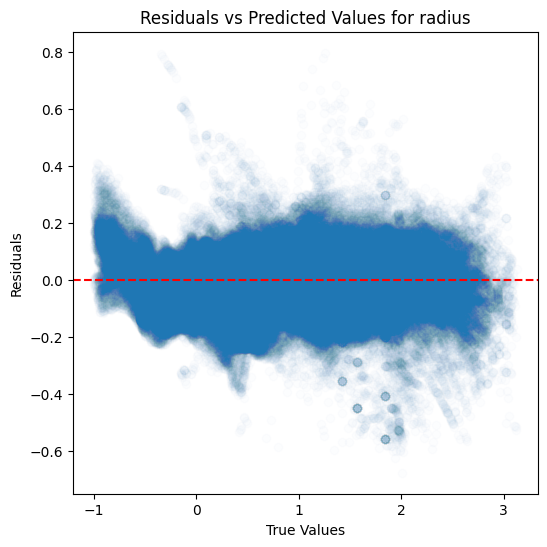

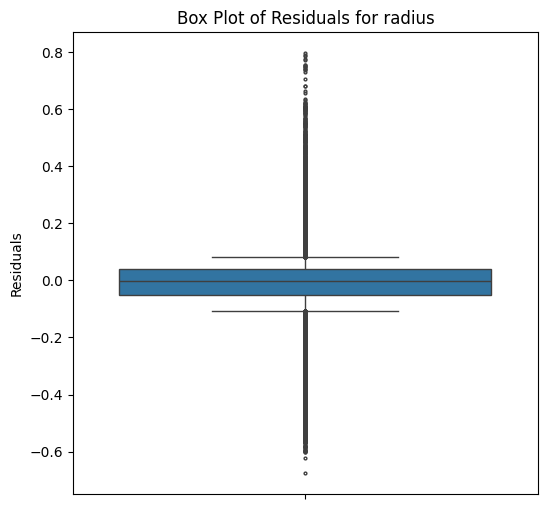

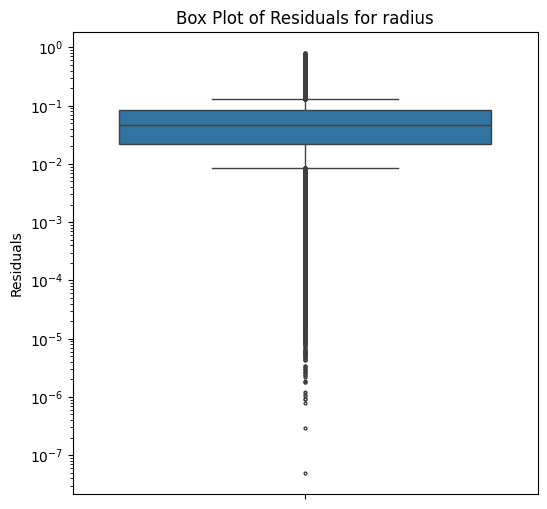

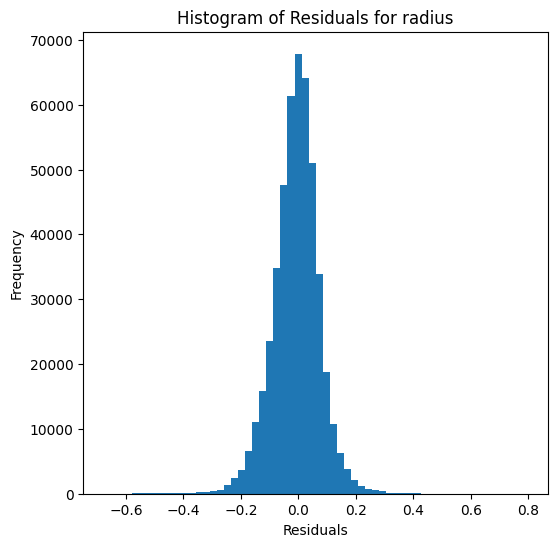

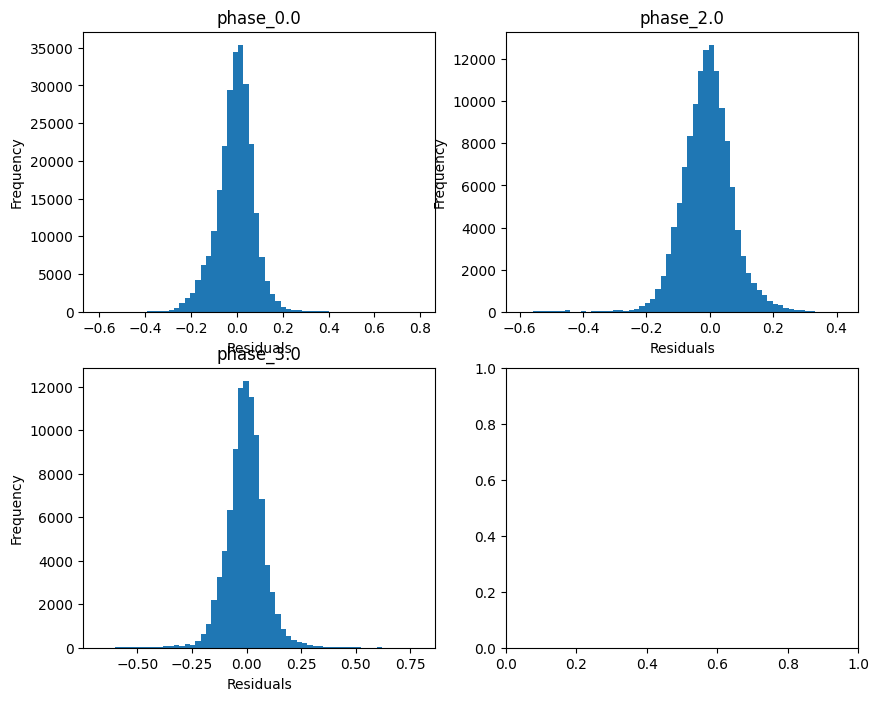

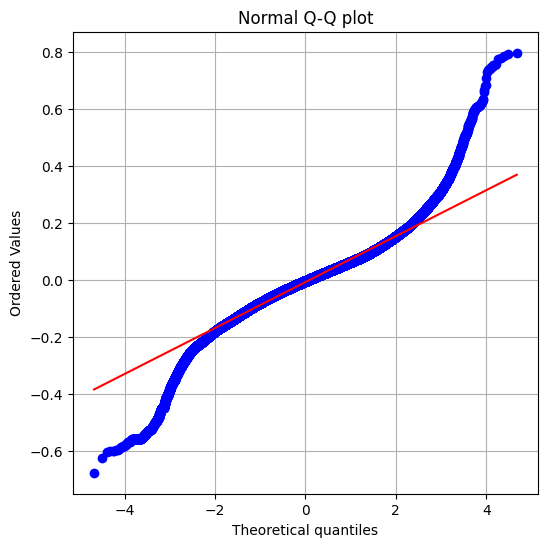

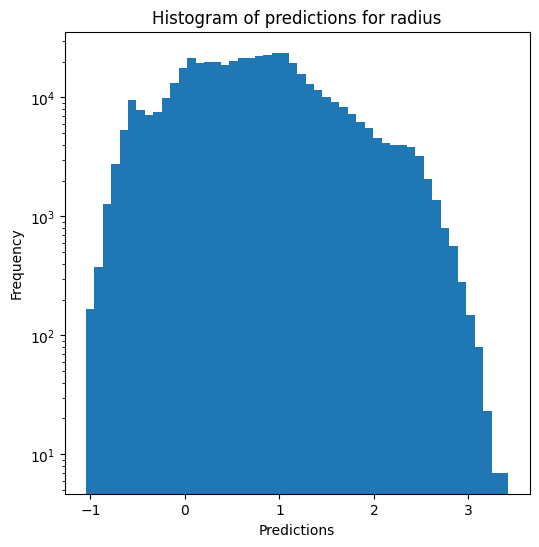

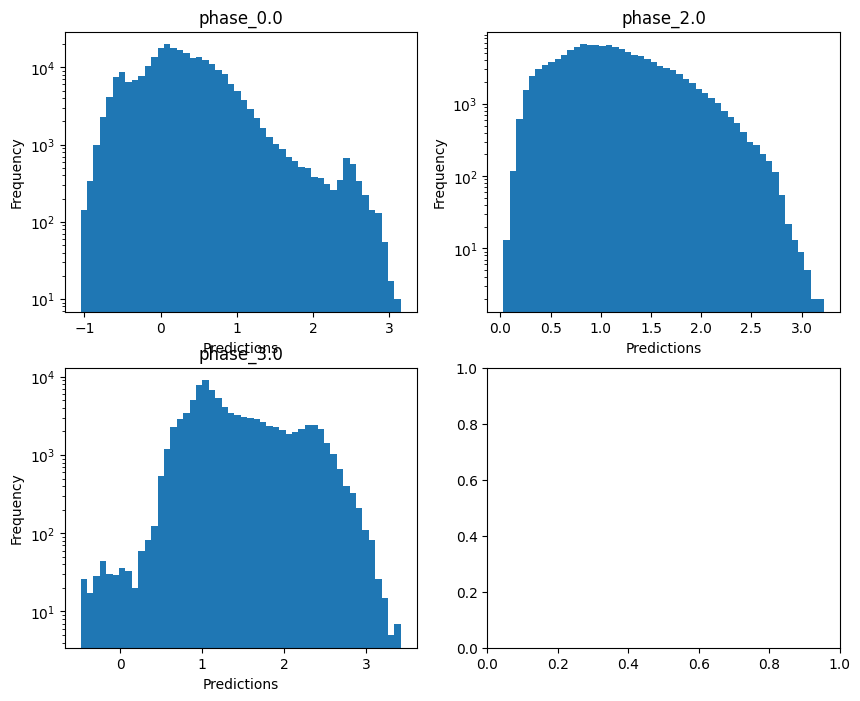

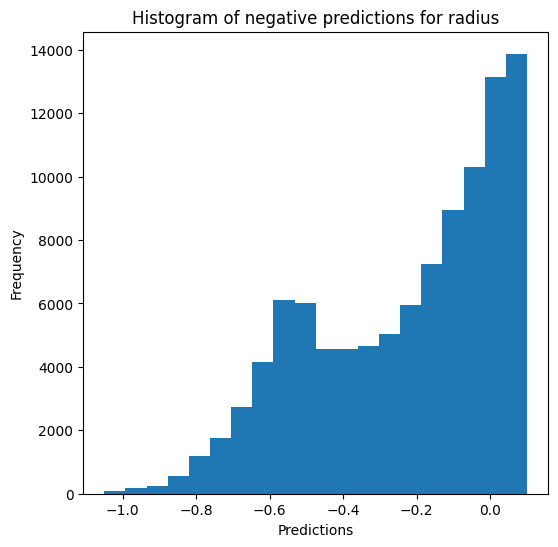

Saving predictions and results...


In [20]:
mlp_evaluator.evaluate_Kfold_results(MLPRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, n_splits=5, random_state=12, override=override, use_preds=use_preds, save=save, show=show, scaler_name=scaler_name,
                                      hidden_layer_sizes = (100, 100, 100, 100), max_iter=20, batch_size=400)

Avec batch_size=auto (200):

plus de 30 minutes pour entrainer un seul split de Kfold avec les paramètres par défaut (1 hidden layer de taille 100)

plus de 15 minutes pour entrainer un seul split de Kfold avec les 1 hidden layer de taille 10

- et max_iter=20, hidden_layer_sizes=(100, 50, 25): ~5 minutes par fold (plutôt bon résultats)
- et max_iter=20, hidden_layer_sizes=(100, 100, 100): ~5 minutes par fold

Avec batch_size=400:


Avec learning_rate= :


hidden_layer_sizes = (100, 100), max_iter=20, batch_size=200 => 17 min pour 2 splits et min_loss de 2.1
RMSE = RVE :  0.984867927459382
RMSE :  2.5335132759292107
MAE :  0.7276983504493552
MedAE :  0.3034009994265745
CORR :  0.9927285673947535
MAX_ER :  169.74348568157313
Percentiles : 75th percentile :  0.5113604728134682 90th percentile :  1.1025928446049704 95th percentile :  2.1347654852226015 99th percentile :  9.897101952249908)

hidden_layer_sizes = (100, 100), max_iter=20, batch_size=400 => 7 min pour 2 splits et min_loss de 2.2
RVE :  0.9797171492755655
RMSE :  2.983208723004754
MAE :  0.9125599339275378
MedAE :  0.43124518658659683
CORR :  0.9920536596906272
MAX_ER :  170.53076478793002
Percentiles : 75th percentile :  0.675744507049632 90th percentile :  1.2421052024331438 95th percentile :  2.441733387262636 99th percentile :  11.925724226452427

hidden_layer_sizes = (100, 100), max_iter=20, batch_size=800 => 3 min pour 2 splits et min_loss de 2.3 et 2.7

hidden_layer_sizes = (100, 100), max_iter=20, batch_size=1600 => 3 min 30 pour 2 splits et min_loss de 7.8 et 3.8

=> batch_size plus grand == plus rapide mais moins bon